In [25]:
%pip install oauth2client

import pandas as pd
import numpy as np
import gspread
from oauth2client.service_account import ServiceAccountCredentials
import matplotlib.pyplot as plt

# ใช้ username และ password แทน service account json
from gspread.exceptions import APIError

import os

# Define the scope for Google Sheets and Drive API
scope = ['https://spreadsheets.google.com/feeds', 'https://www.googleapis.com/auth/drive']

credentials_path = r"..\Service Account\gen-lang-client-0406795509-bc06ec2e33dc.json"
# Use ServiceAccountCredentials and gspread.authorize only if credentials file exists
if os.path.exists(credentials_path):
	credentials = ServiceAccountCredentials.from_json_keyfile_name(credentials_path, scope)
	gc = gspread.authorize(credentials)

	# ── Master (Store Master) from Google Sheets ──────────────────────
	sheet_master = gc.open_by_url("https://docs.google.com/spreadsheets/d/1PiFiOJyxoI6aDR9xdU4HIl8KoDG-50PwYuL4Bm9f8Fk/edit?gid=0#gid=0")
	ws_master = sheet_master.worksheet("Store master")
	Master = pd.DataFrame(ws_master.get_all_records())

	# ── Ref_Survey_Database ─────────────────────────────────────────────
	sheet = gc.open_by_url("https://docs.google.com/spreadsheets/d/1jNP96tfKsehXOS1EknpoO5fkcDbonyu4mEWxxxa3zKE/edit?usp=sharing")
	worksheet = sheet.worksheet("Ref_Survey_Database")
	data = worksheet.get_all_records()
	df_refig_survey = pd.DataFrame(data)
	
	# ── Aircon_Survey_Database ─────────────────────────────────────────────
	sheet = gc.open_by_url("https://docs.google.com/spreadsheets/d/1jNP96tfKsehXOS1EknpoO5fkcDbonyu4mEWxxxa3zKE/edit?usp=sharing")
	worksheet = sheet.worksheet("Aircon_Survey_Database")
	data = worksheet.get_all_records()
	df_aircon_survey = pd.DataFrame(data)


else:
	print(f"Warning: {credentials_path} not found. Skipping Google Sheets import.")


energy_data = pd.read_excel("Energy_Analysis_Report.xlsx")

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [26]:

# ใช้ข้อมูลล่าสุดของแต่ละ Branch Code (ทั้ง Refig และ Aircon)
df_refig_survey_Clean = (
    df_refig_survey
    .dropna(subset=['Branch Code'])
    .assign(Timestamp=pd.to_datetime(df_refig_survey['Timestamp'], errors='coerce'))
    .sort_values(['Branch Code', 'Timestamp'], na_position='first')
    .drop_duplicates(subset=['Branch Code'], keep='last')
    .reset_index(drop=True)
)

df_aircon_survey_clean = (
    df_aircon_survey
    .dropna(subset=['Branch Code'])
    .assign(Timestamp=pd.to_datetime(df_aircon_survey['Timestamp'], errors='coerce'))
    .sort_values(['Branch Code', 'Timestamp'], na_position='first')
    .drop_duplicates(subset=['Branch Code'], keep='last')
    .reset_index(drop=True)
)

In [27]:
merged_critical_df = pd.merge(df_refig_survey_Clean, df_aircon_survey_clean, on='Branch Code', how='outer', 
                        suffixes=('_Refig', '_Aircon')).merge(Master[['Gold text', 'AMM MTN (23)', 'Date Open Store','Status']], 
                        left_on='Branch Code', right_on='Gold text', how='right').drop(columns=['Gold text'] )[Master['Status'] =="A"].merge(energy_data, on='Branch Code', how='left')     

KeyError: 'Branch Code'

In [ ]:
cols = df_refig_survey_Clean.columns.tolist()
qty_cols = [c for c in cols if c.endswith('Qty')]
print("=== จำนวนตู้แต่ละประเภท (Clean data) ===")
for c in qty_cols:
    total = pd.to_numeric(df_refig_survey_Clean[c], errors='coerce').sum()
    stores = (pd.to_numeric(df_refig_survey_Clean[c], errors='coerce') > 0).sum()
    print(f"{c:30s}  รวม {int(total):5d} ตัว  ({stores} สาขา)")

=== จำนวนตู้แต่ละประเภท (Clean data) ===
Ref Open Qty                    รวม  6451 ตัว  (1180 สาขา)
Ref Bev Walk In Qty             รวม   332 ตัว  (193 สาขา)
Ref Frozen3 Door Qty            รวม    91 ตัว  (142 สาขา)
Ref Ice Cream Qty               รวม  2095 ตัว  (1098 สาขา)
Ref Ice Qty                     รวม  1794 ตัว  (1112 สาขา)
Ref Frozen1 Door Qty            รวม  2855 ตัว  (999 สาขา)
Ref Bev Plugin Qty              รวม  1882 ตัว  (741 สาขา)
Ref Frozen2 Door Qty            รวม   129 ตัว  (132 สาขา)
Ref Bev Remote Qty              รวม   620 ตัว  (266 สาขา)
Ref Ss4 Door Qty                รวม  1314 ตัว  (708 สาขา)


In [ ]:
cols = df_refig_survey_Clean.columns.tolist()
type_prefixes = {
    'Open':       'Ref Open',
    'Bev Walk In':'Ref Bev Walk In',
    'Frozen 3D':  'Ref Frozen3 Door',
    'Ice Cream':  'Ref Ice Cream',
    'Ice':        'Ref Ice',
    'Frozen 1D':  'Ref Frozen1 Door',
    'Bev Plugin': 'Ref Bev Plugin',
    'Frozen 2D':  'Ref Frozen2 Door',
    'Bev Remote': 'Ref Bev Remote',
    'SS 4D':      'Ref Ss4 Door',
}

print("=== ยี่ห้อแต่ละประเภท ===")
for label, prefix in type_prefixes.items():
    brand_cols = [c for c in cols if c.startswith(prefix) and 'Brand' in c]
    brands = pd.Series(dtype=str)
    for bc in brand_cols:
        brands = pd.concat([brands, df_refig_survey_Clean[bc].astype(str)], ignore_index=True)
    brands = brands[brands.notna() & (brands != '') & (brands != 'nan') & (brands != '0')]
    top = brands.value_counts().head(8)
    if len(top) > 0:
        print(f"[{label}]: " + ", ".join(f"{b}({n})" for b,n in top.items()))

=== ยี่ห้อแต่ละประเภท ===
[Open]: Themedez(2068), VSR(1865), Panasonic(1265), Carrier(355), Systemform(234), Sanyo(68), SANYO(48), SANYO SMI(42)
[Bev Walk In]: Themedez(99), Panasonic(92), VSR(54), Systemform(10), Sanyo(8), Carrier(7), SANYO(6), Other(4)
[Ice Cream]: LIEBHERR(361), Liebherr(251), Hiron(228), Other(98), The Cool(83), Haier(65), LIEBHERR (38), Panasonic(29)
[Ice]: Panasonic(860), LIEBHERR(412), Themedez(337), Liebherr(269), Hiron(228), The Cool(211), Other(127), VSR(112)
[Bev Plugin]: Themedez(682), VSR(500), Panasonic(257), Carrier(114), Pattana Inter Cool(97), Systemform(76), Sanden(52), Sanyo(15)
[Bev Remote]: Themedez(233), VSR(169), Panasonic(59), Systemform(23), Carrier(17), Pattana Inter Cool(13), COOLPOINT(7), Dixell(5)
[SS 4D]: Themedez(318), VSR(216), Panasonic(206), Sanden(118), Carrier(72), Systemform(65), Other(23), Sanyo(22)


In [ ]:
cols = df_refig_survey_Clean.columns.tolist()
type_prefixes = {
    'Open':       'Ref Open',
    'Bev Walk In':'Ref Bev Walk In',
    'Frozen 3D':  'Ref Frozen3 Door',
    'Ice Cream':  'Ref Ice Cream',
    'Ice':        'Ref Ice',
    'Frozen 1D':  'Ref Frozen1 Door',
    'Bev Plugin': 'Ref Bev Plugin',
    'Frozen 2D':  'Ref Frozen2 Door',
    'Bev Remote': 'Ref Bev Remote',
    'SS 4D':      'Ref Ss4 Door',
}

print("=== สินค้าที่ใส่ในตู้ ===")
for label, prefix in type_prefixes.items():
    prod_cols = [c for c in cols if c.startswith(prefix) and 'Product' in c]
    products = pd.Series(dtype=str)
    for pc in prod_cols:
        products = pd.concat([products, df_refig_survey_Clean[pc].astype(str)], ignore_index=True)
    products = products[products.notna() & (products != '') & (products != 'nan') & (products != '0')]
    top = products.value_counts().head(8)
    if len(top) > 0:
        print(f"[{label}]: " + ", ".join(f"{p}({n})" for p,n in top.items()))
    else:
        print(f"[{label}]: ไม่มีข้อมูล Product")

=== สินค้าที่ใส่ในตู้ ===
[Open]: อื่นๆ(1581), อาหารพร้อมทาน(1100), ยำ/โยเกิร์ต/น้ำผลไม้(985), หมู/ไก่/เนื้อสัตว์(975), แซนวิช/แฮมเบอร์เกอร์/แพนเวิ่ง(591), แซนวิช/แฮมเบอร์เกอร์/แพนเวิ่ง, อาหารพร้อมทาน(289), ยำ/โยเกิร์ต/น้ำผลไม้, อื่นๆ(257), อาหารพร้อมทาน, อื่นๆ(131)
[Bev Walk In]: เครื่องดื่ม(297), อื่นๆ(4), เครื่องดื่ม, อื่นๆ(3), เครื่องดื่ม, อาหารสด(2), อาหารสด(2)
[Frozen 3D]: ไม่มีข้อมูล Product
[Ice Cream]: ไอศครีม(4)
[Ice]: ไอศครีม(4), น้ำแข็ง(3)
[Frozen 1D]: ไม่มีข้อมูล Product
[Bev Plugin]: เครื่องดื่ม(1706), อื่นๆ(81), อาหารสด(40), เครื่องดื่ม, อื่นๆ(18), เครื่องดื่ม, อาหารสด(5), อาหารสด, อื่นๆ(1)
[Frozen 2D]: ไม่มีข้อมูล Product
[Bev Remote]: เครื่องดื่ม(482), อื่นๆ(19), เครื่องดื่ม, อื่นๆ(5), เครื่องดืม(5), อาหารสด(3), เครื่องดื่ม, อาหารสด(3), น้ำอัดลม(2)
[SS 4D]: ไม่มีข้อมูล Product


In [ ]:
cols = df_refig_survey_Clean.columns.tolist()
# ตรวจ brand columns สำหรับ Frozen types
for prefix in ['Ref Frozen', 'Ref Ss4', 'Ref Ice Cream']:
    brand_cols = [c for c in cols if c.startswith(prefix) and 'Brand' in c]
    print(f"{prefix}: brand_cols = {brand_cols[:5]}")
    # ตรวจ Asset No, Model, Type columns ด้วย
    other_cols = [c for c in cols if c.startswith(prefix)][:10]
    print(f"  first cols: {other_cols}")

Ref Frozen: brand_cols = ['Ref Frozen Brand_1', 'Ref Frozen Brand_3', 'Ref Frozen Brand_2', 'Ref Frozen Brand_4', 'Ref Frozen Brand_6']
  first cols: ['Ref Frozen3 Door Qty', 'Ref Frozen1 Door Qty', 'Ref Frozen Brand_1', 'Ref Frozen Asset No_1', 'Ref Frozen Asset No_3', 'Ref Frozen Brand_3', 'Ref Frozen Brand_2', 'Ref Frozen Brand_4', 'Ref Frozen Asset No_2', 'Ref Frozen Asset No_4']
Ref Ss4: brand_cols = ['Ref Ss4 Door Brand_2', 'Ref Ss4 Door Brand_1', 'Ref Ss4 Door Brand_3', 'Ref Ss4 Door Brand_4', 'Ref Ss4 Door Brand_5']
  first cols: ['Ref Ss4 Door Brand_2', 'Ref Ss4 Door Asset No_1', 'Ref Ss4 Door Asset No_2', 'Ref Ss4 Door Brand_1', 'Ref Ss4 Door Qty', 'Ref Ss4 Door Status_1', 'Ref Ss4 Door Status_2', 'Ref Ss4 Door Brand_3', 'Ref Ss4 Door Asset No_3', 'Ref Ss4 Door Status_3']
Ref Ice Cream: brand_cols = ['Ref Ice Cream Brand_1', 'Ref Ice Cream Brand_3', 'Ref Ice Cream Brand_2', 'Ref Ice Cream Brand_4']
  first cols: ['Ref Ice Cream Qty', 'Ref Ice Cream Asset No_1', 'Ref Ice Cream

In [ ]:
cols = df_refig_survey_Clean.columns.tolist()
# ยี่ห้อ Frozen (รวม 1D, 2D, 3D) และ Ice Cream
for label, prefix in [('Frozen (ทุกขนาด)', 'Ref Frozen'), ('Ice Cream', 'Ref Ice Cream'), ('Ice', 'Ref Ice B')]:
    brand_cols = [c for c in cols if c.startswith(prefix) and 'Brand' in c]
    brands = pd.Series(dtype=str)
    for bc in brand_cols:
        brands = pd.concat([brands, df_refig_survey_Clean[bc].astype(str)], ignore_index=True)
    brands = brands[brands.notna() & (brands != '') & (brands != 'nan') & (brands != '0')]
    top = brands.value_counts().head(10)
    print(f"[{label}]: " + ", ".join(f"{b}({n})" for b,n in top.items()))

[Frozen (ทุกขนาด)]: Themedez(849), Sanden(590), Panasonic(512), VSR(314), Carrier(139), iarp(133), Systemform(110), Iarp(67), IARP(65), Sanyo(46)
[Ice Cream]: LIEBHERR(361), Liebherr(251), Hiron(228), Other(98), The Cool(83), Haier(65), LIEBHERR (38), Panasonic(29), Themedez(27), Sanden(20)
[Ice]: Panasonic(831), Themedez(310), The Cool(128), VSR(105), Sanden(88), MIRAGE(55), LIEBHERR(51), Mirage(36), Carrier(30), Other(29)


In [ ]:
# ── ตรวจสอบโครงสร้างข้อมูล ──
print("=== Master columns (ที่มีคำว่า date/open/year) ===")
for c in Master.columns:
    if any(k in c.lower() for k in ['date', 'open', 'year', 'วัน', 'เปิด']):
        print(f"  {c}")

print("\n=== Master columns ทั้งหมด ===")
print(Master.columns.tolist())

print("\n=== df_refig_survey_Clean - Ref Open columns (20 แรก) ===")
open_cols = [c for c in df_refig_survey_Clean.columns if 'Open' in c]
print(open_cols[:20])

=== Master columns (ที่มีคำว่า date/open/year) ===
  Date Open Store
  Already open Month

=== Master columns ทั้งหมด ===
['Gold text', 'GOLD Code', 'Store Name(th) (2)', 'Store Name(en) (3)', 'BU Type (20)', 'ID DD (13)', 'DD Name (14)', 'ID CM (10)', 'CM Name (11)', 'ID AMM (22)', 'AMM MTN (23)', 'AMM MTN DUMMY', 'Tel AMM', 'HUB CODE (17)', 'HUB (18)', 'Date Open Store', 'Status', 'FlowType_Format', 'BU', 'BCM DM Region', 'BCM CM Region', 'FC Flag(Y/N)', 'Oracle Code', 'Address (4)', 'ถนน', 'ตำบล', 'District', 'Province', 'Postal Code', 'Latitude', 'Longitude', 'store name - code', 'ภูมิภาค', 'VP Opts', 'Contract', 'Already open Month', 'MMS Team', 'e-mail SGM', 'e-mail DM BCM', 'e-mail CM BCM']

=== df_refig_survey_Clean - Ref Open columns (20 แรก) ===
['Ref Open Qty', 'Ref Open Asset No_4', 'Ref Open Asset No_2', 'Ref Open Brand_6', 'Ref Open Product_4', 'Ref Open Asset No_3', 'Ref Open Product_2', 'Ref Open Brand_2', 'Ref Open Product_3', 'Ref Open Asset No_6', 'Ref Open Brand_1',

In [ ]:
# import os
# from openpyxl import Workbook
# from openpyxl.styles import PatternFill, Font, Alignment, Border, Side, numbers
# from openpyxl.utils import get_column_letter
# from openpyxl.worksheet.table import Table, TableStyleInfo
# from datetime import datetime

# OUTPUT_PATH = os.path.join(os.path.dirname(os.path.abspath("Refig_Survey_Analysys.ipynb")), "Refig_Survey_Report.xlsx")

# cols = df_refig_survey_Clean.columns.tolist()

# type_prefixes = {
#     'Ref Open':       'Ref Open',
#     'Bev Walk In':    'Ref Bev Walk In',
#     'Frozen 3D':      'Ref Frozen3 Door',
#     'Ice Cream':      'Ref Ice Cream',
#     'Ice':            'Ref Ice',
#     'Frozen 1D':      'Ref Frozen1 Door',
#     'Bev Plugin':     'Ref Bev Plugin',
#     'Frozen 2D':      'Ref Frozen2 Door',
#     'Bev Remote':     'Ref Bev Remote',
#     'SS 4D':          'Ref Ss4 Door',
# }

# qty_cols = [c for c in cols if c.endswith('Qty')]

# wb = Workbook()

# # ─────────────────────────────────────────────────────────────
# # SHEET 1 : Summary Report
# # ─────────────────────────────────────────────────────────────
# ws_sum = wb.active
# ws_sum.title = "Summary"

# HEADER_FILL  = PatternFill("solid", fgColor="1F4E79")
# HEADER_FONT  = Font(bold=True, color="FFFFFF", size=11)
# SUBHDR_FILL  = PatternFill("solid", fgColor="2E75B6")
# SUBHDR_FONT  = Font(bold=True, color="FFFFFF", size=10)
# ALT_FILL     = PatternFill("solid", fgColor="D6E4F0")
# TOTAL_FILL   = PatternFill("solid", fgColor="BDD7EE")
# TOTAL_FONT   = Font(bold=True, size=10)
# BORDER       = Border(
#     left   = Side(style='thin'),
#     right  = Side(style='thin'),
#     top    = Side(style='thin'),
#     bottom = Side(style='thin'),
# )

# def set_cell(ws, row, col, value, fill=None, font=None, align_center=False, number_format=None):
#     cell = ws.cell(row=row, column=col, value=value)
#     cell.border = BORDER
#     if fill:   cell.fill = fill
#     if font:   cell.font = font
#     if align_center: cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
#     if number_format: cell.number_format = number_format
#     return cell

# # ── Title ──
# ws_sum.merge_cells("A1:F1")
# t = ws_sum["A1"]
# t.value = f"สรุปข้อมูลตู้แช่ (Refrigeration Survey)  —  Export: {datetime.today().strftime('%d/%m/%Y')}"
# t.font = Font(bold=True, size=14, color="FFFFFF")
# t.fill = HEADER_FILL
# t.alignment = Alignment(horizontal='center', vertical='center')
# ws_sum.row_dimensions[1].height = 30

# # ── Section A : จำนวนตู้แต่ละประเภท ──
# ws_sum.merge_cells("A2:F2")
# c2 = ws_sum["A2"]
# c2.value = "A.  จำนวนตู้แช่แต่ละประเภท"
# c2.font = SUBHDR_FONT
# c2.fill = SUBHDR_FILL
# c2.alignment = Alignment(horizontal='left', vertical='center')
# ws_sum.row_dimensions[2].height = 20

# headers_A = ["ประเภทตู้แช่", "รหัสคอลัมน์", "จำนวน (ตัว)", "จำนวนสาขา", "เฉลี่ย/สาขา"]
# for ci, h in enumerate(headers_A, 1):
#     set_cell(ws_sum, 3, ci, h, fill=PatternFill("solid", fgColor="2E75B6"),
#              font=Font(bold=True, color="FFFFFF", size=10), align_center=True)

# label_map = {
#     'Ref Open Qty':          'ตู้แช่เปิด (Open)',
#     'Ref Bev Walk In Qty':   'ห้องเย็นเครื่องดื่ม (Walk-in)',
#     'Ref Frozen3 Door Qty':  'ตู้แช่แข็ง 3 ประตู (Frozen 3D)',
#     'Ref Ice Cream Qty':     'ตู้ไอศกรีม (Ice Cream)',
#     'Ref Ice Qty':           'ตู้น้ำแข็ง (Ice)',
#     'Ref Frozen1 Door Qty':  'ตู้แช่แข็ง 1 ประตู (Frozen 1D)',
#     'Ref Bev Plugin Qty':    'ตู้แช่เครื่องดื่ม Plugin (Bev Plugin)',
#     'Ref Frozen2 Door Qty':  'ตู้แช่แข็ง 2 ประตู (Frozen 2D)',
#     'Ref Bev Remote Qty':    'ตู้แช่เครื่องดื่ม Remote (Bev Remote)',
#     'Ref Ss4 Door Qty':      'ตู้ SS 4 ประตู (SS 4D)',
# }

# row = 4
# grand_total_units = 0
# for i, qc in enumerate(qty_cols):
#     nums = pd.to_numeric(df_refig_survey_Clean[qc], errors='coerce')
#     total_u = int(nums.sum())
#     store_c = int((nums > 0).sum())
#     avg = round(total_u / store_c, 2) if store_c > 0 else 0
#     grand_total_units += total_u
#     fill = ALT_FILL if i % 2 == 0 else None
#     set_cell(ws_sum, row, 1, label_map.get(qc, qc), fill=fill)
#     set_cell(ws_sum, row, 2, qc, fill=fill)
#     set_cell(ws_sum, row, 3, total_u, fill=fill, align_center=True, number_format='#,##0')
#     set_cell(ws_sum, row, 4, store_c, fill=fill, align_center=True, number_format='#,##0')
#     set_cell(ws_sum, row, 5, avg, fill=fill, align_center=True, number_format='#,##0.00')
#     row += 1

# # Grand total row
# set_cell(ws_sum, row, 1, "รวมทั้งหมด", fill=TOTAL_FILL, font=TOTAL_FONT)
# set_cell(ws_sum, row, 2, "", fill=TOTAL_FILL)
# set_cell(ws_sum, row, 3, grand_total_units, fill=TOTAL_FILL, font=TOTAL_FONT, align_center=True, number_format='#,##0')
# set_cell(ws_sum, row, 4, "", fill=TOTAL_FILL)
# set_cell(ws_sum, row, 5, "", fill=TOTAL_FILL)
# row += 2

# # ── Section B : ยี่ห้อ (Brand) ──
# ws_sum.merge_cells(f"A{row}:F{row}")
# ws_sum.cell(row=row, column=1).value = "B.  ยี่ห้อตู้แช่แต่ละประเภท (Top 8)"
# ws_sum.cell(row=row, column=1).font = SUBHDR_FONT
# ws_sum.cell(row=row, column=1).fill = SUBHDR_FILL
# ws_sum.cell(row=row, column=1).alignment = Alignment(horizontal='left', vertical='center')
# ws_sum.row_dimensions[row].height = 20
# row += 1

# headers_B = ["ประเภทตู้แช่", "อันดับ", "ยี่ห้อ", "จำนวน (ครั้ง)"]
# for ci, h in enumerate(headers_B, 1):
#     set_cell(ws_sum, row, ci, h, fill=PatternFill("solid", fgColor="2E75B6"),
#              font=Font(bold=True, color="FFFFFF", size=10), align_center=True)
# row += 1

# brand_prefixes = {
#     'ตู้แช่เปิด':              ('Ref Open',       'Ref Open'),
#     'ห้องเย็นเครื่องดื่ม':     ('Bev Walk In',    'Ref Bev Walk In'),
#     'ตู้แช่แข็ง (1D/2D/3D)':  ('Frozen',         'Ref Frozen'),
#     'ตู้ไอศกรีม':              ('Ice Cream',      'Ref Ice Cream'),
#     'ตู้น้ำแข็ง':              ('Ice',            'Ref Ice B'),
#     'ตู้แช่เครื่องดื่ม Plugin': ('Bev Plugin',    'Ref Bev Plugin'),
#     'ตู้แช่เครื่องดื่ม Remote': ('Bev Remote',    'Ref Bev Remote'),
#     'ตู้ SS 4 ประตู':           ('SS 4D',         'Ref Ss4 Door'),
# }

# alt = 0
# for type_label, (_, prefix) in brand_prefixes.items():
#     brand_cols_t = [c for c in cols if c.startswith(prefix) and 'Brand' in c]
#     brands_s = pd.Series(dtype=str)
#     for bc_col in brand_cols_t:
#         brands_s = pd.concat([brands_s, df_refig_survey_Clean[bc_col].astype(str)], ignore_index=True)
#     brands_s = brands_s[brands_s.notna() & (brands_s != '') & (brands_s != 'nan') & (brands_s != '0')]
#     top_brands = brands_s.value_counts().head(8)
#     if len(top_brands) == 0:
#         continue
#     first = True
#     for rank, (brand_name, cnt_b) in enumerate(top_brands.items(), 1):
#         fill = ALT_FILL if alt % 2 == 0 else None
#         set_cell(ws_sum, row, 1, type_label if first else "", fill=fill)
#         set_cell(ws_sum, row, 2, rank, fill=fill, align_center=True)
#         set_cell(ws_sum, row, 3, brand_name, fill=fill)
#         set_cell(ws_sum, row, 4, int(cnt_b), fill=fill, align_center=True, number_format='#,##0')
#         first = False
#         row += 1
#     alt += 1

# # ── Section C : สินค้า (Product) ──
# row += 1
# ws_sum.merge_cells(f"A{row}:F{row}")
# ws_sum.cell(row=row, column=1).value = "C.  สินค้าในตู้แต่ละประเภท (Top 8)"
# ws_sum.cell(row=row, column=1).font = SUBHDR_FONT
# ws_sum.cell(row=row, column=1).fill = SUBHDR_FILL
# ws_sum.cell(row=row, column=1).alignment = Alignment(horizontal='left', vertical='center')
# ws_sum.row_dimensions[row].height = 20
# row += 1

# headers_C = ["ประเภทตู้แช่", "อันดับ", "สินค้า", "จำนวน (ครั้ง)"]
# for ci, h in enumerate(headers_C, 1):
#     set_cell(ws_sum, row, ci, h, fill=PatternFill("solid", fgColor="2E75B6"),
#              font=Font(bold=True, color="FFFFFF", size=10), align_center=True)
# row += 1

# product_prefixes = {
#     'ตู้แช่เปิด':               'Ref Open',
#     'ห้องเย็นเครื่องดื่ม':      'Ref Bev Walk In',
#     'ตู้ไอศกรีม':               'Ref Ice Cream',
#     'ตู้น้ำแข็ง':               'Ref Ice',
#     'ตู้แช่เครื่องดื่ม Plugin':  'Ref Bev Plugin',
#     'ตู้แช่เครื่องดื่ม Remote':  'Ref Bev Remote',
# }

# alt2 = 0
# for type_label, prefix in product_prefixes.items():
#     prod_cols_t = [c for c in cols if c.startswith(prefix) and 'Product' in c]
#     products_s = pd.Series(dtype=str)
#     for pc_col in prod_cols_t:
#         products_s = pd.concat([products_s, df_refig_survey_Clean[pc_col].astype(str)], ignore_index=True)
#     products_s = products_s[products_s.notna() & (products_s != '') & (products_s != 'nan') & (products_s != '0')]
#     top_prods = products_s.value_counts().head(8)
#     if len(top_prods) == 0:
#         continue
#     first = True
#     for rank, (prod_name, cnt_p) in enumerate(top_prods.items(), 1):
#         fill = ALT_FILL if alt2 % 2 == 0 else None
#         set_cell(ws_sum, row, 1, type_label if first else "", fill=fill)
#         set_cell(ws_sum, row, 2, rank, fill=fill, align_center=True)
#         set_cell(ws_sum, row, 3, prod_name, fill=fill)
#         set_cell(ws_sum, row, 4, int(cnt_p), fill=fill, align_center=True, number_format='#,##0')
#         first = False
#         row += 1
#     alt2 += 1

# # column widths
# for col_idx, w in zip(range(1, 7), [40, 30, 18, 14, 14, 14]):
#     ws_sum.column_dimensions[get_column_letter(col_idx)].width = w

# # ─────────────────────────────────────────────────────────────
# # SHEET 2 : Raw Data (Refig Survey Clean)
# # ─────────────────────────────────────────────────────────────
# ws_raw = wb.create_sheet("Raw Data - Refig")
# raw_df = df_refig_survey_Clean.copy()

# # Write header
# for ci, col_name in enumerate(raw_df.columns, 1):
#     cell = ws_raw.cell(row=1, column=ci, value=col_name)
#     cell.fill = HEADER_FILL
#     cell.font = HEADER_FONT
#     cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
#     cell.border = BORDER

# # Write data
# for ri, data_row in enumerate(raw_df.itertuples(index=False), 2):
#     fill = ALT_FILL if ri % 2 == 0 else None
#     for ci, val in enumerate(data_row, 1):
#         cell = ws_raw.cell(row=ri, column=ci, value=val if val != '' else None)
#         cell.border = BORDER
#         if fill: cell.fill = fill
#         cell.alignment = Alignment(vertical='center')

# # Excel Table on Raw sheet
# table_ref = f"A1:{get_column_letter(len(raw_df.columns))}{len(raw_df)+1}"
# tbl = Table(displayName="RefigSurveyRaw", ref=table_ref)
# tbl.tableStyleInfo = TableStyleInfo(name="TableStyleMedium2", showFirstColumn=False,
#                                     showLastColumn=False, showRowStripes=True, showColumnStripes=False)
# ws_raw.add_table(tbl)

# # auto-width first 15 cols only (others may be too many)
# for ci in range(1, min(16, len(raw_df.columns)+1)):
#     col_vals = [str(raw_df.iloc[r, ci-1]) for r in range(min(200, len(raw_df)))]
#     max_len = max([len(str(raw_df.columns[ci-1]))] + [len(v) for v in col_vals if v not in ('', 'nan', 'None')])
#     ws_raw.column_dimensions[get_column_letter(ci)].width = min(max_len + 2, 40)

# ws_raw.freeze_panes = "A2"

# # ─────────────────────────────────────────────────────────────
# # SHEET 3 : Raw Data (Merged)
# # ─────────────────────────────────────────────────────────────
# ws_merged = wb.create_sheet("Raw Data - Merged")
# mg_df = merged_critical_df.copy()

# for ci, col_name in enumerate(mg_df.columns, 1):
#     cell = ws_merged.cell(row=1, column=ci, value=col_name)
#     cell.fill = HEADER_FILL
#     cell.font = HEADER_FONT
#     cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
#     cell.border = BORDER

# for ri, data_row in enumerate(mg_df.itertuples(index=False), 2):
#     fill = ALT_FILL if ri % 2 == 0 else None
#     for ci, val in enumerate(data_row, 1):
#         cell = ws_merged.cell(row=ri, column=ci, value=val if val != '' else None)
#         cell.border = BORDER
#         if fill: cell.fill = fill
#         cell.alignment = Alignment(vertical='center')

# table_ref2 = f"A1:{get_column_letter(len(mg_df.columns))}{len(mg_df)+1}"
# tbl2 = Table(displayName="MergedSurveyRaw", ref=table_ref2)
# tbl2.tableStyleInfo = TableStyleInfo(name="TableStyleMedium6", showFirstColumn=False,
#                                      showLastColumn=False, showRowStripes=True, showColumnStripes=False)
# ws_merged.add_table(tbl2)
# ws_merged.freeze_panes = "A2"

# for ci in range(1, min(16, len(mg_df.columns)+1)):
#     col_vals = [str(mg_df.iloc[r, ci-1]) for r in range(min(200, len(mg_df)))]
#     max_len = max([len(str(mg_df.columns[ci-1]))] + [len(v) for v in col_vals if v not in ('', 'nan', 'None')])
#     ws_merged.column_dimensions[get_column_letter(ci)].width = min(max_len + 2, 40)

# # ─────────────────────────────────────────────────────────────
# # Save
# # ─────────────────────────────────────────────────────────────
# wb.save(OUTPUT_PATH)
# print(f"✅ Saved: {OUTPUT_PATH}")
# print(f"   Sheet 'Summary'          : {row-1} rows")
# print(f"   Sheet 'Raw Data - Refig' : {len(raw_df)} rows × {len(raw_df.columns)} cols")
# print(f"   Sheet 'Raw Data - Merged': {len(mg_df)} rows × {len(mg_df.columns)} cols")

In [ ]:
print("Master GOLD Code sample:", Master['GOLD Code'].head(5).tolist())
print("Branch Code sample:", df_refig_survey_Clean['Branch Code'].head(5).tolist())
print("Date Open Store sample:", Master['Date Open Store'].head(5).tolist())
print("Already open Month sample:", Master['Already open Month'].head(5).tolist())
print("Status unique:", Master['Status'].unique()[:10])
print("Open Product cols:", [c for c in df_refig_survey_Clean.columns if 'Open' in c and 'Product' in c])
print("Ref Open Qty:", df_refig_survey_Clean['Ref Open Qty'].describe())

Master GOLD Code sample: [11101, 11102, 11103, 11104, 11106]
Branch Code sample: [11235, 21002, 21005, 21007, 21009]
Date Open Store sample: ['1/9/1995', '15/1/1994', '25/11/1994', '17/6/1995', '1/2/1996']
Already open Month sample: [366, 386, 376, 369, 361]
Status unique: ['A' 'I' 0]
Open Product cols: ['Ref Open Product_4', 'Ref Open Product_2', 'Ref Open Product_3', 'Ref Open Product_1', 'Ref Open Product_5', 'Ref Open Product_6', 'Ref Open Product_7', 'Ref Open Product_8', 'Ref Open Product_9', 'Ref Open Product_12', 'Ref Open Product_11', 'Ref Open Product_10', 'Ref Open Product_13', 'Ref Open Product_24', 'Ref Open Product_55', 'Ref Open Product_42', 'Ref Open Product_32', 'Ref Open Product_38', 'Ref Open Product_63', 'Ref Open Product_57', 'Ref Open Product_50', 'Ref Open Product_59', 'Ref Open Product_31', 'Ref Open Product_39', 'Ref Open Product_15', 'Ref Open Product_35', 'Ref Open Product_52', 'Ref Open Product_18', 'Ref Open Product_54', 'Ref Open Product_66', 'Ref Open Pro

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np
from matplotlib import rcParams
import warnings
warnings.filterwarnings('ignore')

rcParams['font.family'] = 'Tahoma'
rcParams['axes.unicode_minus'] = False

TODAY = pd.Timestamp.today().normalize()

# ═══════════════════════════════════════════════════════════
# 1.  Prepare Master — active stores only
# ═══════════════════════════════════════════════════════════
master_active = Master[Master['Status'] == 'A'].copy()
master_active['Date Open Store'] = pd.to_datetime(
    master_active['Date Open Store'], dayfirst=True, errors='coerce')
master_active['Already open Month'] = pd.to_numeric(
    master_active['Already open Month'], errors='coerce')
master_active['Store Age (yrs)'] = (
    (TODAY - master_active['Date Open Store']).dt.days / 365.25).round(1)
master_active['Open Year'] = master_active['Date Open Store'].dt.year

# ═══════════════════════════════════════════════════════════
# 2.  Identify stores with Ref Open + อาหารพร้อมทาน
# ═══════════════════════════════════════════════════════════
ref_df = df_refig_survey_Clean.copy()
ref_df['Ref Open Qty Num'] = pd.to_numeric(ref_df['Ref Open Qty'], errors='coerce').fillna(0)
open_prod_cols = [c for c in ref_df.columns if c.startswith('Ref Open Product')]

keywords = ['อาหาร', 'พร้อมทาน', 'แซนวิช', 'หมู', 'ยำ', 'โยเกิร์ต', 'น้ำผลไม้']
prod_text = ref_df[open_prod_cols].astype(str)
prod_mask = prod_text.apply(lambda col: col.str.contains('|'.join(keywords), na=False)).any(axis=1)
qty_mask = ref_df['Ref Open Qty Num'] >= 1

rte_stores = ref_df[qty_mask & prod_mask][
    ['Branch Code', 'Branch Name', 'DM Area', 'CM Area', 'Ref Open Qty Num']].copy()
rte_stores['Branch Code'] = rte_stores['Branch Code'].astype(str).str.strip()
print(f"สาขาที่มีตู้ Ref Open + อาหารพร้อมทาน: {len(rte_stores)} สาขา")

# ═══════════════════════════════════════════════════════════
# 3.  Merge กับ Master เพื่อได้ Date Open Store
# ═══════════════════════════════════════════════════════════
master_active['GOLD Code'] = master_active['GOLD Code'].astype(str).str.strip()
analysis_df = rte_stores.merge(
    master_active[['GOLD Code', 'Store Name(th) (2)', 'Date Open Store',
                   'Store Age (yrs)', 'Open Year', 'Already open Month',
                   'BCM DM Region', 'BCM CM Region', 'HUB (18)', 'Province']],
    left_on='Branch Code', right_on='GOLD Code', how='left'
)
analysis_df.drop(columns=['GOLD Code'], inplace=True)

# fallback: ใช้ Already open Month ถ้า Date ไม่มี
no_date = analysis_df['Store Age (yrs)'].isna()
analysis_df.loc[no_date, 'Store Age (yrs)'] = (
    pd.to_numeric(analysis_df.loc[no_date, 'Already open Month'], errors='coerce') / 12).round(1)

analysis_df['Store Age (yrs)'] = pd.to_numeric(analysis_df['Store Age (yrs)'], errors='coerce')
analysis_df['Open Year'] = pd.to_numeric(analysis_df['Open Year'], errors='coerce')

print(f"หลัง merge: {len(analysis_df)} สาขา  |  Date พบ: {analysis_df['Date Open Store'].notna().sum()}")
print(f"Store Age range: {analysis_df['Store Age (yrs)'].min():.1f} – {analysis_df['Store Age (yrs)'].max():.1f} ปี")
analysis_df.head(3)

สาขาที่มีตู้ Ref Open + อาหารพร้อมทาน: 1156 สาขา
หลัง merge: 1156 สาขา  |  Date พบ: 1156
Store Age range: 0.0 – 19.9 ปี


,Branch Code,Branch Name,DM Area,CM Area,Ref Open Qty Num,Store Name(th) (2),Date Open Store,Store Age (yrs),Open Year,Already open Month,BCM DM Region,BCM CM Region,HUB (18),Province
0,21002,MBC อุดมสุข,น.ส.รัชดาพร อีศรัตน์,น.ส.กรรณิการ์ พุทธวงค์,6.0,MBC อุดมสุข,2006-05-14,19.9,2006,238.0,#N/A,#N/A,MBC อุดมสุข,กรุงเทพมหานคร
1,21005,MBC ชินเขต,น.ส.รัชดาพร อีศรัตน์,น.ส.นิตยา สมจิตร,7.0,MBC ชินเขต,2008-07-29,17.7,2008,211.0,#N/A,#N/A,MBC BCP สุวินทวงศ์,กรุงเทพมหานคร
2,21007,MBC บางพลี,นายอนุกูล ศรีลัดดา,น.ส.วีรนันท์ แสงใส,4.0,MBC บางพลี,2010-07-31,15.7,2010,187.0,#N/A,#N/A,BCM ชุมชนเกาะเรียน พระนครศรีอยุธยา,สมุทรปราการ


In [ ]:
def classify_risk(age):
    if pd.isna(age):   return 'Unknown'
    if age < 5:        return '1_Low'
    elif age < 8:      return '2_Medium'
    elif age < 11:     return '3_High'
    else:              return '4_Critical'

RISK_LABEL = {
    '1_Low':      '🟢 Low  (< 5 ปี)',
    '2_Medium':   '🟡 Medium (5–7 ปี)',
    '3_High':     '🔴 High (8–10 ปี)',
    '4_Critical': '⛔ Critical (> 10 ปี)',
    'Unknown':    'ไม่ทราบ'
}
RISK_COLORS_HEX = {
    '1_Low':      '#2ecc71',
    '2_Medium':   '#f1c40f',
    '3_High':     '#e67e22',
    '4_Critical': '#c0392b',
    'Unknown':    '#95a5a6'
}
RISK_ORDER_KEYS = ['1_Low', '2_Medium', '3_High', '4_Critical', 'Unknown']

analysis_df['Risk Key']   = analysis_df['Store Age (yrs)'].apply(classify_risk)
analysis_df['Risk Level'] = analysis_df['Risk Key'].map(RISK_LABEL)
analysis_df['Risk Color'] = analysis_df['Risk Key'].map(RISK_COLORS_HEX)

risk_summary = (analysis_df.groupby('Risk Key', sort=True)
    .agg(Stores=('Branch Code','count'),
         Units=('Ref Open Qty Num','sum'),
         AvgAge=('Store Age (yrs)','mean'))
    .reindex([k for k in RISK_ORDER_KEYS if k in analysis_df['Risk Key'].unique()])
    .reset_index())
risk_summary['AvgAge'] = risk_summary['AvgAge'].round(1)
risk_summary['Units']  = risk_summary['Units'].astype(int)
risk_summary['Label']  = risk_summary['Risk Key'].map(RISK_LABEL)

print("=== Risk Summary ===")
for _, r in risk_summary.iterrows():
    print(f"  {r['Label']:30s}  {r['Stores']:4d} สาขา  |  {r['Units']:5d} ตัว  |  อายุเฉลี่ย {r['AvgAge']:.1f} ปี")

=== Risk Summary ===
  🟢 Low  (< 5 ปี)                  354 สาขา  |   2102 ตัว  |  อายุเฉลี่ย 2.9 ปี
  🟡 Medium (5–7 ปี)                494 สาขา  |   2864 ตัว  |  อายุเฉลี่ย 6.5 ปี
  🔴 High (8–10 ปี)                 152 สาขา  |    817 ตัว  |  อายุเฉลี่ย 8.9 ปี
  ⛔ Critical (> 10 ปี)             156 สาขา  |    528 ตัว  |  อายุเฉลี่ย 13.2 ปี


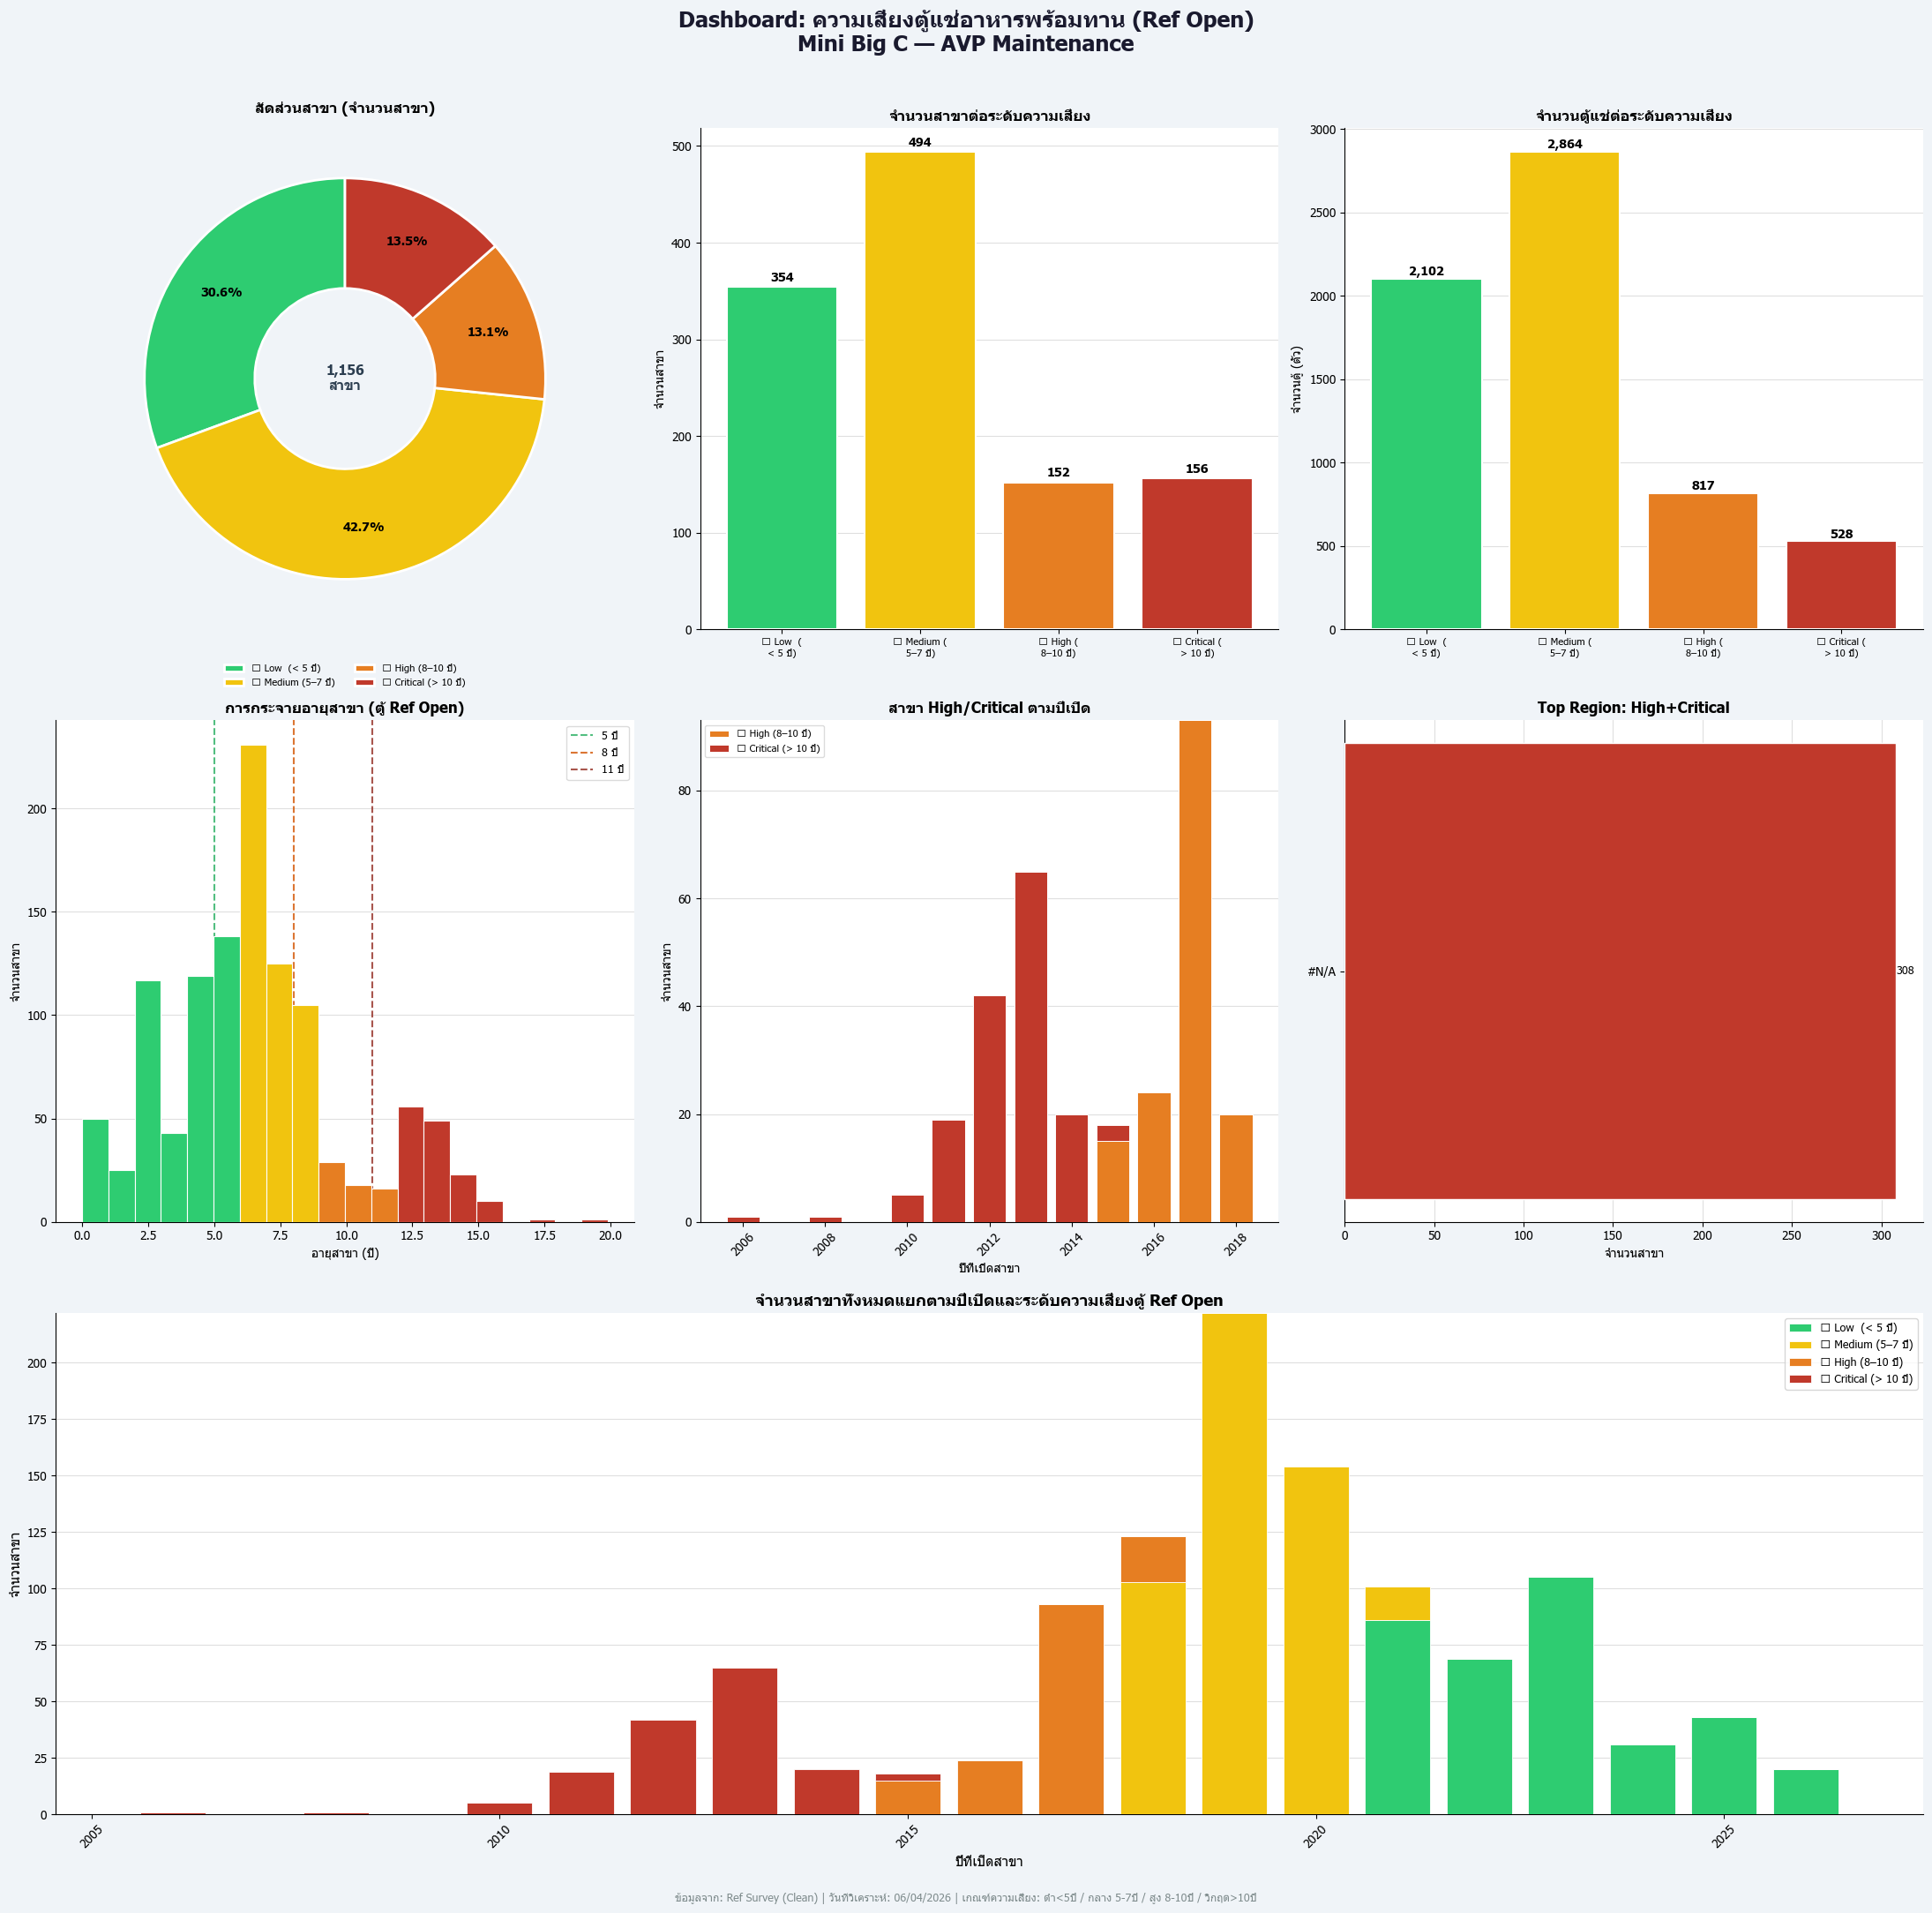

✅ Dashboard saved


In [ ]:
# ═══════════════════════════════════════════════════════════
# 5.  Dashboard — 6 Charts
# ═══════════════════════════════════════════════════════════
fig = plt.figure(figsize=(22, 22), facecolor='#f0f4f8')
fig.suptitle('Dashboard: ความเสี่ยงตู้แช่อาหารพร้อมทาน (Ref Open)\nMini Big C — AVP Maintenance',
             fontsize=18, fontweight='bold', y=0.98, color='#1a1a2e')

PALETTE = [RISK_COLORS_HEX[k] for k in RISK_ORDER_KEYS if k in analysis_df['Risk Key'].unique()]
LABELS  = risk_summary['Label'].tolist()
RISK_KEY_LIST = [k for k in RISK_ORDER_KEYS if k in analysis_df['Risk Key'].unique()]

# ── Chart 1: Donut — สัดส่วนสาขา ──
ax1 = fig.add_subplot(3, 3, 1)
wedges, texts, autotexts = ax1.pie(
    risk_summary['Stores'], labels=None, colors=PALETTE,
    autopct='%1.1f%%', startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2))
for at in autotexts: at.set_fontsize(10); at.set_fontweight('bold')
ax1.legend(wedges, LABELS, loc='upper center', bbox_to_anchor=(0.5, -0.05),
           fontsize=8, ncol=2, frameon=False)
ax1.set_title('สัดส่วนสาขา (จำนวนสาขา)', fontsize=12, fontweight='bold', pad=12)
total_stores = risk_summary['Stores'].sum()
ax1.text(0, 0, f'{total_stores:,}\nสาขา', ha='center', va='center',
         fontsize=11, fontweight='bold', color='#2c3e50')

# ── Chart 2: Bar — จำนวนสาขาต่อ Risk ──
ax2 = fig.add_subplot(3, 3, 2)
bars = ax2.bar(range(len(risk_summary)), risk_summary['Stores'], color=PALETTE,
               edgecolor='white', linewidth=1.5, zorder=3)
for bar, v in zip(bars, risk_summary['Stores']):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
             f'{v:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_xticks(range(len(LABELS)))
ax2.set_xticklabels([l.replace('(','(\n') for l in LABELS], fontsize=8)
ax2.set_ylabel('จำนวนสาขา', fontsize=10); ax2.set_title('จำนวนสาขาต่อระดับความเสี่ยง', fontsize=12, fontweight='bold')
ax2.yaxis.grid(True, alpha=0.4, zorder=0); ax2.set_axisbelow(True)
ax2.spines[['top','right']].set_visible(False)

# ── Chart 3: Bar — จำนวนตู้ต่อ Risk ──
ax3 = fig.add_subplot(3, 3, 3)
bars3 = ax3.bar(range(len(risk_summary)), risk_summary['Units'], color=PALETTE,
                edgecolor='white', linewidth=1.5, zorder=3)
for bar, v in zip(bars3, risk_summary['Units']):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
             f'{v:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax3.set_xticks(range(len(LABELS)))
ax3.set_xticklabels([l.replace('(','(\n') for l in LABELS], fontsize=8)
ax3.set_ylabel('จำนวนตู้ (ตัว)', fontsize=10); ax3.set_title('จำนวนตู้แช่ต่อระดับความเสี่ยง', fontsize=12, fontweight='bold')
ax3.yaxis.grid(True, alpha=0.4, zorder=0); ax3.set_axisbelow(True)
ax3.spines[['top','right']].set_visible(False)

# ── Chart 4: Histogram — การกระจายอายุ ──
ax4 = fig.add_subplot(3, 3, 4)
ages = analysis_df['Store Age (yrs)'].dropna()
n, bins, patches = ax4.hist(ages, bins=20, edgecolor='white', linewidth=0.8, color='#3498db', zorder=3)
# ระบายสีตาม risk zone
for patch, left in zip(patches, bins[:-1]):
    if left < 5:    patch.set_facecolor('#2ecc71')
    elif left < 8:  patch.set_facecolor('#f1c40f')
    elif left < 11: patch.set_facecolor('#e67e22')
    else:           patch.set_facecolor('#c0392b')
ax4.axvline(5,  color='#27ae60', linestyle='--', lw=1.5, alpha=0.8, label='5 ปี')
ax4.axvline(8,  color='#d35400', linestyle='--', lw=1.5, alpha=0.8, label='8 ปี')
ax4.axvline(11, color='#922b21', linestyle='--', lw=1.5, alpha=0.8, label='11 ปี')
ax4.set_xlabel('อายุสาขา (ปี)', fontsize=10); ax4.set_ylabel('จำนวนสาขา', fontsize=10)
ax4.set_title('การกระจายอายุสาขา (ตู้ Ref Open)', fontsize=12, fontweight='bold')
ax4.legend(fontsize=9, framealpha=0.7)
ax4.yaxis.grid(True, alpha=0.4, zorder=0); ax4.set_axisbelow(True)
ax4.spines[['top','right']].set_visible(False)

# ── Chart 5: Open Year Bar (สาขาที่เปิดแต่ละปี ของกลุ่ม High+Critical) ──
ax5 = fig.add_subplot(3, 3, 5)
hc_df = analysis_df[analysis_df['Risk Key'].isin(['3_High', '4_Critical'])].copy()
hc_df['Open Year'] = hc_df['Open Year'].fillna(0).astype(int)
yr_counts = hc_df[hc_df['Open Year'] > 2000].groupby(['Open Year','Risk Key']).size().unstack(fill_value=0)
yr_counts = yr_counts.reindex(columns=[k for k in RISK_ORDER_KEYS if k in yr_counts.columns])
bottom = np.zeros(len(yr_counts))
for key in yr_counts.columns:
    color = RISK_COLORS_HEX[key]
    ax5.bar(yr_counts.index, yr_counts[key], bottom=bottom, color=color,
            edgecolor='white', linewidth=0.7, label=RISK_LABEL[key], zorder=3)
    bottom += yr_counts[key].values
ax5.set_xlabel('ปีที่เปิดสาขา'); ax5.set_ylabel('จำนวนสาขา')
ax5.set_title('สาขา High/Critical ตามปีเปิด', fontsize=12, fontweight='bold')
ax5.legend(fontsize=8, framealpha=0.7)
ax5.tick_params(axis='x', rotation=45)
ax5.yaxis.grid(True, alpha=0.4, zorder=0); ax5.set_axisbelow(True)
ax5.spines[['top','right']].set_visible(False)

# ── Chart 6: Top 15 Region/Area — High+Critical ──
ax6 = fig.add_subplot(3, 3, 6)
region_col = 'BCM CM Region' if 'BCM CM Region' in analysis_df.columns else 'CM Area'
hc_region = (hc_df.groupby(region_col).size().sort_values(ascending=True).tail(15))
colors6 = ['#c0392b' if v >= hc_region.quantile(0.75) else '#e67e22'
           for v in hc_region.values]
ax6.barh(hc_region.index, hc_region.values, color=colors6, edgecolor='white', zorder=3)
for i, v in enumerate(hc_region.values):
    ax6.text(v+0.3, i, str(v), va='center', fontsize=9)
ax6.set_xlabel('จำนวนสาขา'); ax6.set_title('Top Region: High+Critical', fontsize=12, fontweight='bold')
ax6.xaxis.grid(True, alpha=0.4, zorder=0); ax6.set_axisbelow(True)
ax6.spines[['top','right']].set_visible(False)

# ── Chart 7–8: Box plot อายุตาม region + Scatter ──
ax7 = fig.add_subplot(3, 1, 3)
open_yr_all = analysis_df[analysis_df['Open Year'] > 2000].copy()
yr_risk = open_yr_all.groupby(['Open Year','Risk Key']).size().unstack(fill_value=0)
yr_risk = yr_risk.reindex(columns=[k for k in RISK_ORDER_KEYS if k in yr_risk.columns])
bottom7 = np.zeros(len(yr_risk))
for key in yr_risk.columns:
    color = RISK_COLORS_HEX[key]
    ax7.bar(yr_risk.index, yr_risk[key], bottom=bottom7, color=color,
            edgecolor='white', linewidth=0.6, label=RISK_LABEL[key], zorder=3, width=0.8)
    bottom7 += yr_risk[key].values
ax7.set_xlabel('ปีที่เปิดสาขา', fontsize=11); ax7.set_ylabel('จำนวนสาขา', fontsize=11)
ax7.set_title('จำนวนสาขาทั้งหมดแยกตามปีเปิดและระดับความเสี่ยงตู้ Ref Open',
              fontsize=13, fontweight='bold')
ax7.legend(fontsize=9, framealpha=0.8, loc='upper right')
ax7.tick_params(axis='x', rotation=45)
ax7.yaxis.grid(True, alpha=0.4, zorder=0); ax7.set_axisbelow(True)
ax7.spines[['top','right']].set_visible(False)

# ── footnote ──
fig.text(0.5, 0.005,
         f'ข้อมูลจาก: Ref Survey (Clean) | วันที่วิเคราะห์: {TODAY.strftime("%d/%m/%Y")} | '
         f'เกณฑ์ความเสี่ยง: ต่ำ<5ปี / กลาง 5-7ปี / สูง 8-10ปี / วิกฤต>10ปี',
         ha='center', fontsize=9, color='#7f8c8d', style='italic')

plt.tight_layout(rect=[0, 0.015, 1, 0.97])
plt.savefig(r'G:\My Drive\00. Web Projects\Air_Ref_Servey\Pyhon ANL\RefOpen_Risk_Dashboard.png',
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("✅ Dashboard saved")

In [ ]:
from openpyxl import Workbook
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from openpyxl.worksheet.table import Table, TableStyleInfo
from openpyxl.drawing.image import Image as XLImage
import os

OUT_XL = r'G:\My Drive\00. Web Projects\Air_Ref_Servey\Pyhon ANL\RefOpen_Risk_Report.xlsx'

# ── Style helpers ──
def xfill(hex_str):   return PatternFill("solid", fgColor=hex_str.lstrip('#'))
def xfont(bold=False, color="000000", size=10): return Font(bold=bold, color=color, size=size)
BORDER = Border(
    left=Side(style='thin'), right=Side(style='thin'),
    top=Side(style='thin'),  bottom=Side(style='thin'))

RISK_HEX = {'1_Low':'2ecc71','2_Medium':'f1c40f','3_High':'e67e22','4_Critical':'c0392b','Unknown':'95a5a6'}
RISK_FONT_COLOR = {'1_Low':'FFFFFF','2_Medium':'1a1a1a','3_High':'FFFFFF','4_Critical':'FFFFFF','Unknown':'FFFFFF'}

def write_cell(ws, row, col, val, fill=None, bold=False, font_color='000000',
               size=10, center=False, wrap=False, num_fmt=None, border=True):
    c = ws.cell(row=row, column=col, value=val)
    if fill:  c.fill = fill
    c.font  = Font(bold=bold, color=font_color, size=size)
    c.alignment = Alignment(horizontal='center' if center else 'left',
                            vertical='center', wrap_text=wrap)
    if border: c.border = BORDER
    if num_fmt: c.number_format = num_fmt
    return c

wb = Workbook()

# ═══════════════════════════════════════════════════════════
# SHEET 1 : Dashboard Image
# ═══════════════════════════════════════════════════════════
ws_dash = wb.active
ws_dash.title = "Dashboard"
ws_dash.sheet_view.showGridLines = False
IMG_PATH = r'G:\My Drive\00. Web Projects\Air_Ref_Servey\Pyhon ANL\RefOpen_Risk_Dashboard.png'
if os.path.exists(IMG_PATH):
    img = XLImage(IMG_PATH)
    img.anchor = 'A1'
    ws_dash.add_image(img)
    ws_dash.column_dimensions['A'].width = 160
    ws_dash.row_dimensions[1].height = 900

# ═══════════════════════════════════════════════════════════
# SHEET 2 : Summary
# ═══════════════════════════════════════════════════════════
ws_s = wb.create_sheet("Risk Summary")
ws_s.sheet_view.showGridLines = False

# Title
ws_s.merge_cells("A1:H1")
write_cell(ws_s, 1, 1,
    f'สรุปความเสี่ยงตู้แช่อาหารพร้อมทาน (Ref Open) — Mini Big C  |  วันที่: {TODAY.strftime("%d/%m/%Y")}',
    fill=xfill('1F4E79'), bold=True, font_color='FFFFFF', size=14, center=True)
ws_s.row_dimensions[1].height = 32

# Sub-title
for c, txt in enumerate(['ระดับความเสี่ยง','คำอธิบาย','จำนวนสาขา','สัดส่วน (%)','จำนวนตู้ (ตัว)','สัดส่วนตู้ (%)','อายุเฉลี่ย (ปี)','Action แนะนำ'], 1):
    write_cell(ws_s, 2, c, txt, fill=xfill('2E75B6'), bold=True, font_color='FFFFFF', size=10, center=True)
ws_s.row_dimensions[2].height = 20

total_stores2 = risk_summary['Stores'].sum()
total_units2  = risk_summary['Units'].sum()

actions = {
    '1_Low':      'Monitor ปกติ — Survey ปีละ 1 ครั้ง',
    '2_Medium':   'Preventive Maintenance ก่อนครบ 8 ปี',
    '3_High':     'PM เร่งด่วน + วางแผน Replace ภายใน 1-2 ปี',
    '4_Critical': 'Replace ทันที — ความเสี่ยงสูง (เกิน 10 ปี)',
    'Unknown':    'ตรวจสอบ Date Open Store'
}
desc = {
    '1_Low':      'อายุ < 5 ปี — ยังอยู่ในช่วงใช้งานปกติ',
    '2_Medium':   'อายุ 5–7 ปี — เริ่มเข้าสู่ช่วงเฝ้าระวัง',
    '3_High':     'อายุ 8–10 ปี — ใกล้ถึงอายุการใช้งานมาตรฐาน',
    '4_Critical': 'อายุ > 10 ปี — เกินอายุการใช้งานมาตรฐาน',
    'Unknown':    'ไม่มีข้อมูลวันเปิดสาขา'
}

row3 = 3
for _, r in risk_summary.iterrows():
    k = r['Risk Key']
    pct_s = r['Stores'] / total_stores2 * 100
    pct_u = r['Units']  / total_units2  * 100
    fg = xfill(RISK_HEX[k])
    fc = RISK_FONT_COLOR[k]
    write_cell(ws_s, row3, 1, r['Label'],    fill=fg, bold=True, font_color=fc, center=True)
    write_cell(ws_s, row3, 2, desc[k],       fill=fg, font_color=fc, wrap=True)
    write_cell(ws_s, row3, 3, r['Stores'],   fill=fg, bold=True, font_color=fc, center=True, num_fmt='#,##0')
    write_cell(ws_s, row3, 4, round(pct_s,1),fill=fg, font_color=fc, center=True, num_fmt='0.0"%"')
    write_cell(ws_s, row3, 5, r['Units'],    fill=fg, bold=True, font_color=fc, center=True, num_fmt='#,##0')
    write_cell(ws_s, row3, 6, round(pct_u,1),fill=fg, font_color=fc, center=True, num_fmt='0.0"%"')
    write_cell(ws_s, row3, 7, r['AvgAge'],   fill=fg, font_color=fc, center=True, num_fmt='0.0')
    write_cell(ws_s, row3, 8, actions[k],    fill=fg, font_color=fc, wrap=True)
    ws_s.row_dimensions[row3].height = 28
    row3 += 1

# Total row
write_cell(ws_s, row3, 1, 'รวมทั้งหมด', fill=xfill('BDD7EE'), bold=True, center=True)
write_cell(ws_s, row3, 2, '', fill=xfill('BDD7EE'))
write_cell(ws_s, row3, 3, total_stores2, fill=xfill('BDD7EE'), bold=True, center=True, num_fmt='#,##0')
write_cell(ws_s, row3, 4, 100.0, fill=xfill('BDD7EE'), center=True, num_fmt='0.0"%"')
write_cell(ws_s, row3, 5, total_units2, fill=xfill('BDD7EE'), bold=True, center=True, num_fmt='#,##0')
write_cell(ws_s, row3, 6, 100.0, fill=xfill('BDD7EE'), center=True, num_fmt='0.0"%"')
write_cell(ws_s, row3, 7, '', fill=xfill('BDD7EE'))
write_cell(ws_s, row3, 8, '', fill=xfill('BDD7EE'))
ws_s.row_dimensions[row3].height = 22

# column widths
for ci, w in zip(range(1,9), [28, 40, 14, 12, 14, 12, 14, 45]):
    ws_s.column_dimensions[get_column_letter(ci)].width = w

# ═══════════════════════════════════════════════════════════
# SHEET 3 : High & Critical Store List (Action List)
# ═══════════════════════════════════════════════════════════
ws_hc = wb.create_sheet("Action List (High+Critical)")
hc_export = analysis_df[analysis_df['Risk Key'].isin(['3_High','4_Critical'])].copy()
hc_export = hc_export.sort_values(['Risk Key','Store Age (yrs)'], ascending=[True, False])

hc_cols = ['Branch Code','Branch Name','Store Name(th) (2)','CM Area','DM Area',
           'Province','HUB (18)','Date Open Store','Store Age (yrs)',
           'Ref Open Qty Num','Risk Level']
hc_out = hc_export[[c for c in hc_cols if c in hc_export.columns]].copy()
hc_out['Date Open Store'] = hc_out['Date Open Store'].dt.strftime('%d/%m/%Y') if hasattr(hc_out['Date Open Store'].dtype, 'tz') else hc_out['Date Open Store'].astype(str)

col_headers = {
    'Branch Code':'รหัสสาขา','Branch Name':'ชื่อสาขา','Store Name(th) (2)':'ชื่อสาขา (Master)',
    'CM Area':'CM Area','DM Area':'DM Area','Province':'จังหวัด','HUB (18)':'HUB',
    'Date Open Store':'วันเปิดสาขา','Store Age (yrs)':'อายุ (ปี)',
    'Ref Open Qty Num':'จำนวนตู้ Ref Open','Risk Level':'ระดับความเสี่ยง'
}
display_cols = [c for c in hc_cols if c in hc_out.columns]
header_labels = [col_headers.get(c, c) for c in display_cols]

# Header row
for ci, h_label in enumerate(header_labels, 1):
    write_cell(ws_hc, 1, ci, h_label, fill=xfill('1F4E79'), bold=True,
               font_color='FFFFFF', size=10, center=True)
ws_hc.row_dimensions[1].height = 22

# Data rows
for ri, (_, row_data) in enumerate(hc_out.iterrows(), 2):
    k = row_data.get('Risk Key', '') if 'Risk Key' in row_data else ''
    risk_str = str(row_data.get('Risk Level', ''))
    if '4_Critical' in str(hc_export.loc[row_data.name, 'Risk Key'] if row_data.name in hc_export.index else '') or 'Critical' in risk_str:
        row_fill = xfill('FADBD8')
    else:
        row_fill = xfill('FDEBD0') if ri % 2 == 0 else xfill('FEF9E7')
    for ci, col_name in enumerate(display_cols, 1):
        val = row_data.get(col_name, '')
        nf = '#,##0.0' if col_name == 'Store Age (yrs)' else ('#,##0' if col_name == 'Ref Open Qty Num' else None)
        write_cell(ws_hc, ri, ci, val, fill=row_fill, num_fmt=nf,
                   center=(col_name in ['Branch Code','Store Age (yrs)','Ref Open Qty Num','Date Open Store']))

# Excel Table
tbl_ref = f"A1:{get_column_letter(len(display_cols))}{len(hc_out)+1}"
tbl_hc = Table(displayName="ActionList", ref=tbl_ref)
tbl_hc.tableStyleInfo = TableStyleInfo(name="TableStyleMedium3",
    showRowStripes=True, showFirstColumn=False, showLastColumn=False)
ws_hc.add_table(tbl_hc)
ws_hc.freeze_panes = "A2"

# auto width
for ci, col_name in enumerate(display_cols, 1):
    vals = [str(col_headers.get(col_name, col_name))] + [str(v) for v in hc_out[col_name].head(100)]
    w = min(max(len(v) for v in vals) + 2, 40)
    ws_hc.column_dimensions[get_column_letter(ci)].width = w

print(f"Action List: {len(hc_out)} สาขา (High: {(hc_export['Risk Key']=='3_High').sum()}, Critical: {(hc_export['Risk Key']=='4_Critical').sum()})")

# ═══════════════════════════════════════════════════════════
# SHEET 4 : Full Data — All stores with risk
# ═══════════════════════════════════════════════════════════
ws_all = wb.create_sheet("All Stores - Ref Open")
all_export = analysis_df.sort_values(['Risk Key','Store Age (yrs)'], ascending=[True, False]).copy()
all_export = all_export[[c for c in hc_cols if c in all_export.columns]]

all_display = [c for c in hc_cols if c in all_export.columns]
all_labels  = [col_headers.get(c, c) for c in all_display]

for ci, h_label in enumerate(all_labels, 1):
    write_cell(ws_all, 1, ci, h_label, fill=xfill('1F4E79'), bold=True,
               font_color='FFFFFF', size=10, center=True)
ws_all.row_dimensions[1].height = 22

for ri, (_, row_data) in enumerate(all_export.iterrows(), 2):
    rl = str(row_data.get('Risk Level', ''))
    if 'Critical' in rl:   rf = xfill('FADBD8')
    elif 'High' in rl:     rf = xfill('FDEBD0')
    elif 'Medium' in rl:   rf = xfill('FEFDE7') if ri%2==0 else None
    else:                   rf = xfill('EAFAF1') if ri%2==0 else None
    for ci, col_name in enumerate(all_display, 1):
        val = row_data.get(col_name, '')
        nf = '#,##0.0' if col_name == 'Store Age (yrs)' else ('#,##0' if col_name == 'Ref Open Qty Num' else None)
        write_cell(ws_all, ri, ci, val, fill=rf, num_fmt=nf,
                   center=(col_name in ['Branch Code','Store Age (yrs)','Ref Open Qty Num','Date Open Store']))

tbl_all_ref = f"A1:{get_column_letter(len(all_display))}{len(all_export)+1}"
tbl_all = Table(displayName="AllStoresRefOpen", ref=tbl_all_ref)
tbl_all.tableStyleInfo = TableStyleInfo(name="TableStyleMedium2", showRowStripes=True)
ws_all.add_table(tbl_all)
ws_all.freeze_panes = "A2"
for ci, col_name in enumerate(all_display, 1):
    vals = [str(all_labels[ci-1])] + [str(v) for v in all_export[col_name].head(100)]
    ws_all.column_dimensions[get_column_letter(ci)].width = min(max(len(v) for v in vals)+2, 40)

# ── Save ──
wb.save(OUT_XL)
print(f"\n✅ Saved: {OUT_XL}")
print(f"   Sheet 'Dashboard'           : รูป Dashboard")
print(f"   Sheet 'Risk Summary'        : สรุปความเสี่ยง 4 ระดับ")
print(f"   Sheet 'Action List'         : {len(hc_out)} สาขา High+Critical")
print(f"   Sheet 'All Stores - Ref Open': {len(all_export)} สาขา ทุก Risk Level")

Action List: 308 สาขา (High: 152, Critical: 156)

✅ Saved: G:\My Drive\00. Web Projects\Air_Ref_Servey\Pyhon ANL\RefOpen_Risk_Report.xlsx
   Sheet 'Dashboard'           : รูป Dashboard
   Sheet 'Risk Summary'        : สรุปความเสี่ยง 4 ระดับ
   Sheet 'Action List'         : 308 สาขา High+Critical
   Sheet 'All Stores - Ref Open': 1156 สาขา ทุก Risk Level


In [29]:
# ── ตรวจ merge key ──
print("energy_data Store ID sample:", energy_data['Store ID'].dropna().head(5).tolist())
print("df_refig_survey Branch Code sample:", df_refig_survey_Clean['Branch Code'].head(5).tolist())
print("master_active GOLD Code sample:", master_active['GOLD Code'].head(5).tolist())
print("energy_data rows:", len(energy_data))
print("energy_data kWh 2025 non-null:", energy_data['kWh 2025'].notna().sum())
print("Frozen Status cols:", [c for c in df_refig_survey_Clean.columns if 'Frozen' in c and 'Status' in c][:5])
print("Frozen Status sample:")
st_cols = [c for c in df_refig_survey_Clean.columns if 'Frozen' in c and 'Status' in c]
print(df_refig_survey_Clean[df_refig_survey_Clean['Ref Frozen1 Door Qty'].astype(str).str.extract(r'(\d+)', expand=False).fillna('0').astype(int) > 0][st_cols[:3]].head(5).to_string())

# จำนวนตู้ทั้งหมดต่อ store
all_ref_qty_cols = [c for c in df_refig_survey_Clean.columns if c.endswith('Qty') and c.startswith('Ref')]
print("\nAll Ref Qty cols:", all_ref_qty_cols)

energy_data Store ID sample: [21718.0, 22696.0, 22520.0, 22697.0, 22406.0]
df_refig_survey Branch Code sample: [11235, 21002, 21005, 21007, 21009]
master_active GOLD Code sample: ['11101', '11102', '11104', '11106', '11107']
energy_data rows: 1582
energy_data kWh 2025 non-null: 1582
Frozen Status cols: ['Ref Frozen Status_2', 'Ref Frozen Status_4', 'Ref Frozen Status_1', 'Ref Frozen Status_3', 'Ref Frozen Status_6']
Frozen Status sample:
   Ref Frozen Status_2 Ref Frozen Status_4 Ref Frozen Status_1
2               ใช้งาน                                  ใช้งาน
4                                                       ใช้งาน
8               ใช้งาน                                  ใช้งาน
12              ใช้งาน              ใช้งาน              ใช้งาน
13              ใช้งาน                                  ใช้งาน

All Ref Qty cols: ['Ref Open Qty', 'Ref Bev Walk In Qty', 'Ref Frozen3 Door Qty', 'Ref Ice Cream Qty', 'Ref Ice Qty', 'Ref Frozen1 Door Qty', 'Ref Bev Plugin Qty', 'Ref Frozen2 Do

In [30]:
import warnings; warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from matplotlib import rcParams
from scipy import stats
rcParams['font.family'] = 'Tahoma'
rcParams['axes.unicode_minus'] = False

TODAY = pd.Timestamp.today().normalize()

# ═══════════════════════════════════════════════════════════════════
# PART A — FROZEN RISK ANALYSIS
# ═══════════════════════════════════════════════════════════════════

# ── Risk classification (Frozen อายุมาตรฐาน 12 ปี) ──
def classify_frozen_risk(age):
    if pd.isna(age):   return 'Unknown'
    if age < 5:        return '1_Low'
    elif age < 9:      return '2_Medium'
    elif age < 13:     return '3_High'
    else:              return '4_Critical'

F_LABEL = {
    '1_Low':      '🟢 Low  (< 5 ปี)',
    '2_Medium':   '🟡 Medium (5–8 ปี)',
    '3_High':     '🔴 High (9–12 ปี)',
    '4_Critical': '⛔ Critical (> 12 ปี)',
    'Unknown':    'ไม่ทราบ'
}
F_COLOR = {'1_Low':'#2ecc71','2_Medium':'#f1c40f','3_High':'#e67e22','4_Critical':'#c0392b','Unknown':'#95a5a6'}
F_ORDER = ['1_Low','2_Medium','3_High','4_Critical','Unknown']

# ── Frozen stores: มี Frozen ≥ 1 ตู้ ──
ref_f = df_refig_survey_Clean.copy()
for qc in ['Ref Frozen1 Door Qty','Ref Frozen2 Door Qty','Ref Frozen3 Door Qty']:
    ref_f[qc] = pd.to_numeric(ref_f[qc], errors='coerce').fillna(0)

ref_f['Frozen Total Qty'] = ref_f['Ref Frozen1 Door Qty'] + ref_f['Ref Frozen2 Door Qty'] + ref_f['Ref Frozen3 Door Qty']
frozen_stores = ref_f[ref_f['Frozen Total Qty'] >= 1][
    ['Branch Code','Branch Name','DM Area','CM Area',
     'Ref Frozen1 Door Qty','Ref Frozen2 Door Qty','Ref Frozen3 Door Qty','Frozen Total Qty']].copy()
frozen_stores['Branch Code'] = frozen_stores['Branch Code'].astype(str).str.strip()
print(f"สาขาที่มี Frozen ≥ 1 ตัว: {len(frozen_stores)} สาขา  |  ตู้รวม: {int(frozen_stores['Frozen Total Qty'].sum())} ตัว")

# ── Merge กับ Master ──
frozen_df = frozen_stores.merge(
    master_active[['GOLD Code','Store Name(th) (2)','Date Open Store','Already open Month',
                   'Store Age (yrs)','Open Year','BCM CM Region','HUB (18)','Province']],
    left_on='Branch Code', right_on='GOLD Code', how='left'
).drop(columns=['GOLD Code'])

no_date_f = frozen_df['Store Age (yrs)'].isna()
frozen_df.loc[no_date_f,'Store Age (yrs)'] = (
    pd.to_numeric(frozen_df.loc[no_date_f,'Already open Month'], errors='coerce') / 12).round(1)
frozen_df['Store Age (yrs)'] = pd.to_numeric(frozen_df['Store Age (yrs)'], errors='coerce')

frozen_df['Risk Key']   = frozen_df['Store Age (yrs)'].apply(classify_frozen_risk)
frozen_df['Risk Level'] = frozen_df['Risk Key'].map(F_LABEL)

# ── Frozen Risk Summary ──
f_risk_sum = (frozen_df.groupby('Risk Key', sort=True)
    .agg(Stores=('Branch Code','count'),
         Units=('Frozen Total Qty','sum'),
         U_1D=('Ref Frozen1 Door Qty','sum'),
         U_2D=('Ref Frozen2 Door Qty','sum'),
         U_3D=('Ref Frozen3 Door Qty','sum'),
         AvgAge=('Store Age (yrs)','mean'))
    .reindex([k for k in F_ORDER if k in frozen_df['Risk Key'].unique()])
    .reset_index())
f_risk_sum['AvgAge'] = f_risk_sum['AvgAge'].round(1)
for c in ['Units','U_1D','U_2D','U_3D']: f_risk_sum[c] = f_risk_sum[c].astype(int)
f_risk_sum['Label'] = f_risk_sum['Risk Key'].map(F_LABEL)

print("\n=== Frozen Risk Summary ===")
for _, r in f_risk_sum.iterrows():
    print(f"  {r['Label']:32s}  {r['Stores']:4d} สาขา | {r['Units']:5d} ตัว (1D:{r['U_1D']} 2D:{r['U_2D']} 3D:{r['U_3D']}) | อายุเฉลี่ย {r['AvgAge']:.1f} ปี")

สาขาที่มี Frozen ≥ 1 ตัว: 1133 สาขา  |  ตู้รวม: 3304 ตัว

=== Frozen Risk Summary ===
  🟢 Low  (< 5 ปี)                    350 สาขา |  1308 ตัว (1D:1264 2D:22 3D:22) | อายุเฉลี่ย 2.9 ปี
  🟡 Medium (5–8 ปี)                  582 สาขา |  1631 ตัว (1D:1479 2D:64 3D:88) | อายุเฉลี่ย 6.8 ปี
  🔴 High (9–12 ปี)                   117 สาขา |   209 ตัว (1D:121 2D:55 3D:33) | อายุเฉลี่ย 11.4 ปี
  ⛔ Critical (> 12 ปี)                84 สาขา |   156 ตัว (1D:79 2D:52 3D:25) | อายุเฉลี่ย 14.0 ปี


In [31]:
# ═══════════════════════════════════════════════════════════════════
# PART B — ENERGY + REFRIG MASTER TABLE
# ═══════════════════════════════════════════════════════════════════

# ── normalise keys ──
energy = energy_data.copy()
energy['Store ID'] = pd.to_numeric(energy['Store ID'], errors='coerce').astype('Int64').astype(str).str.strip()
energy['kWh 2025']     = pd.to_numeric(energy['kWh 2025'],    errors='coerce')
energy['kWh 2024']     = pd.to_numeric(energy['kWh 2024'],    errors='coerce')
energy['kWh/sqm 2025'] = pd.to_numeric(energy['kWh/sqm 2025'],errors='coerce')
energy['Net sqm']      = pd.to_numeric(energy['Net sqm'],      errors='coerce')

# ── รวมจำนวนตู้แช่ทุกประเภทต่อสาขา ──
ref_qty_cols = [c for c in df_refig_survey_Clean.columns if c.endswith('Qty') and c.startswith('Ref')]
refig_sum = df_refig_survey_Clean[['Branch Code'] + ref_qty_cols].copy()
for c in ref_qty_cols:
    refig_sum[c] = pd.to_numeric(refig_sum[c], errors='coerce').fillna(0)
refig_sum['Total Ref Units'] = refig_sum[ref_qty_cols].sum(axis=1)
refig_sum['Frozen Total']    = (refig_sum['Ref Frozen1 Door Qty'] + refig_sum['Ref Frozen2 Door Qty'] + refig_sum['Ref Frozen3 Door Qty'])
refig_sum['Ref Open Qty_n']  = refig_sum['Ref Open Qty']
refig_sum['Branch Code']     = refig_sum['Branch Code'].astype(str).str.strip()

# ── Merge: energy ← refig survey ← master_active ──
master_key = master_active[['GOLD Code','Store Age (yrs)','Date Open Store','Open Year','BCM CM Region',
                             'Province','HUB (18)','AMM MTN (23)','Store Name(th) (2)']].copy()
master_key['GOLD Code'] = master_key['GOLD Code'].astype(str).str.strip()

energy_ref = (energy
    .merge(refig_sum[['Branch Code','Total Ref Units','Frozen Total','Ref Open Qty_n'] + ref_qty_cols],
           left_on='Store ID', right_on='Branch Code', how='left')
    .merge(master_key, left_on='Store ID', right_on='GOLD Code', how='left')
    .drop(columns=['Branch Code','GOLD Code'], errors='ignore'))

energy_ref['Total Ref Units'] = energy_ref['Total Ref Units'].fillna(0)
energy_ref['Frozen Total']    = energy_ref['Frozen Total'].fillna(0)
energy_ref['Store Age (yrs)'] = pd.to_numeric(energy_ref['Store Age (yrs)'], errors='coerce')

# ── เพิ่ม Risk Level ──
energy_ref['Risk Key']   = energy_ref['Store Age (yrs)'].apply(
    lambda x: '1_Low' if (pd.notna(x) and x<5) else ('2_Medium' if (pd.notna(x) and x<9) else
              ('3_High' if (pd.notna(x) and x<13) else ('4_Critical' if pd.notna(x) else 'Unknown'))))
energy_ref['Risk Level'] = energy_ref['Risk Key'].map(F_LABEL)

# ── filter: only stores with kWh > 0 and survey data ──
energy_valid = energy_ref[
    (energy_ref['kWh 2025'] > 0) &
    (energy_ref['Total Ref Units'] > 0) &
    (energy_ref['Store Age (yrs)'].notna())
].copy()

print(f"Energy x Refig valid records: {len(energy_valid)} สาขา")
print(f"  kWh 2025 range: {energy_valid['kWh 2025'].min():,.0f} – {energy_valid['kWh 2025'].max():,.0f}")
print(f"  Store Age: {energy_valid['Store Age (yrs)'].min():.1f} – {energy_valid['Store Age (yrs)'].max():.1f} ปี")
print(f"  Total Ref Units: {energy_valid['Total Ref Units'].min():.0f} – {energy_valid['Total Ref Units'].max():.0f}")
print(f"\nCorrelation matrix:")
corr = energy_valid[['kWh 2025','kWh/sqm 2025','Store Age (yrs)','Total Ref Units','Frozen Total','Net sqm']].corr()
print(corr.round(3))

Energy x Refig valid records: 1198 สาขา
  kWh 2025 range: 5,315 – 429,964
  Store Age: 0.1 – 19.9 ปี
  Total Ref Units: 1 – 45

Correlation matrix:
                 kWh 2025  kWh/sqm 2025  Store Age (yrs)  Total Ref Units  \
kWh 2025            1.000         0.588            0.326            0.066   
kWh/sqm 2025        0.588         1.000            0.206           -0.119   
Store Age (yrs)     0.326         0.206            1.000           -0.367   
Total Ref Units     0.066        -0.119           -0.367            1.000   
Frozen Total       -0.016        -0.159           -0.442            0.648   
Net sqm             0.410        -0.355            0.091            0.213   

                 Frozen Total  Net sqm  
kWh 2025               -0.016    0.410  
kWh/sqm 2025           -0.159   -0.355  
Store Age (yrs)        -0.442    0.091  
Total Ref Units         0.648    0.213  
Frozen Total            1.000    0.183  
Net sqm                 0.183    1.000  


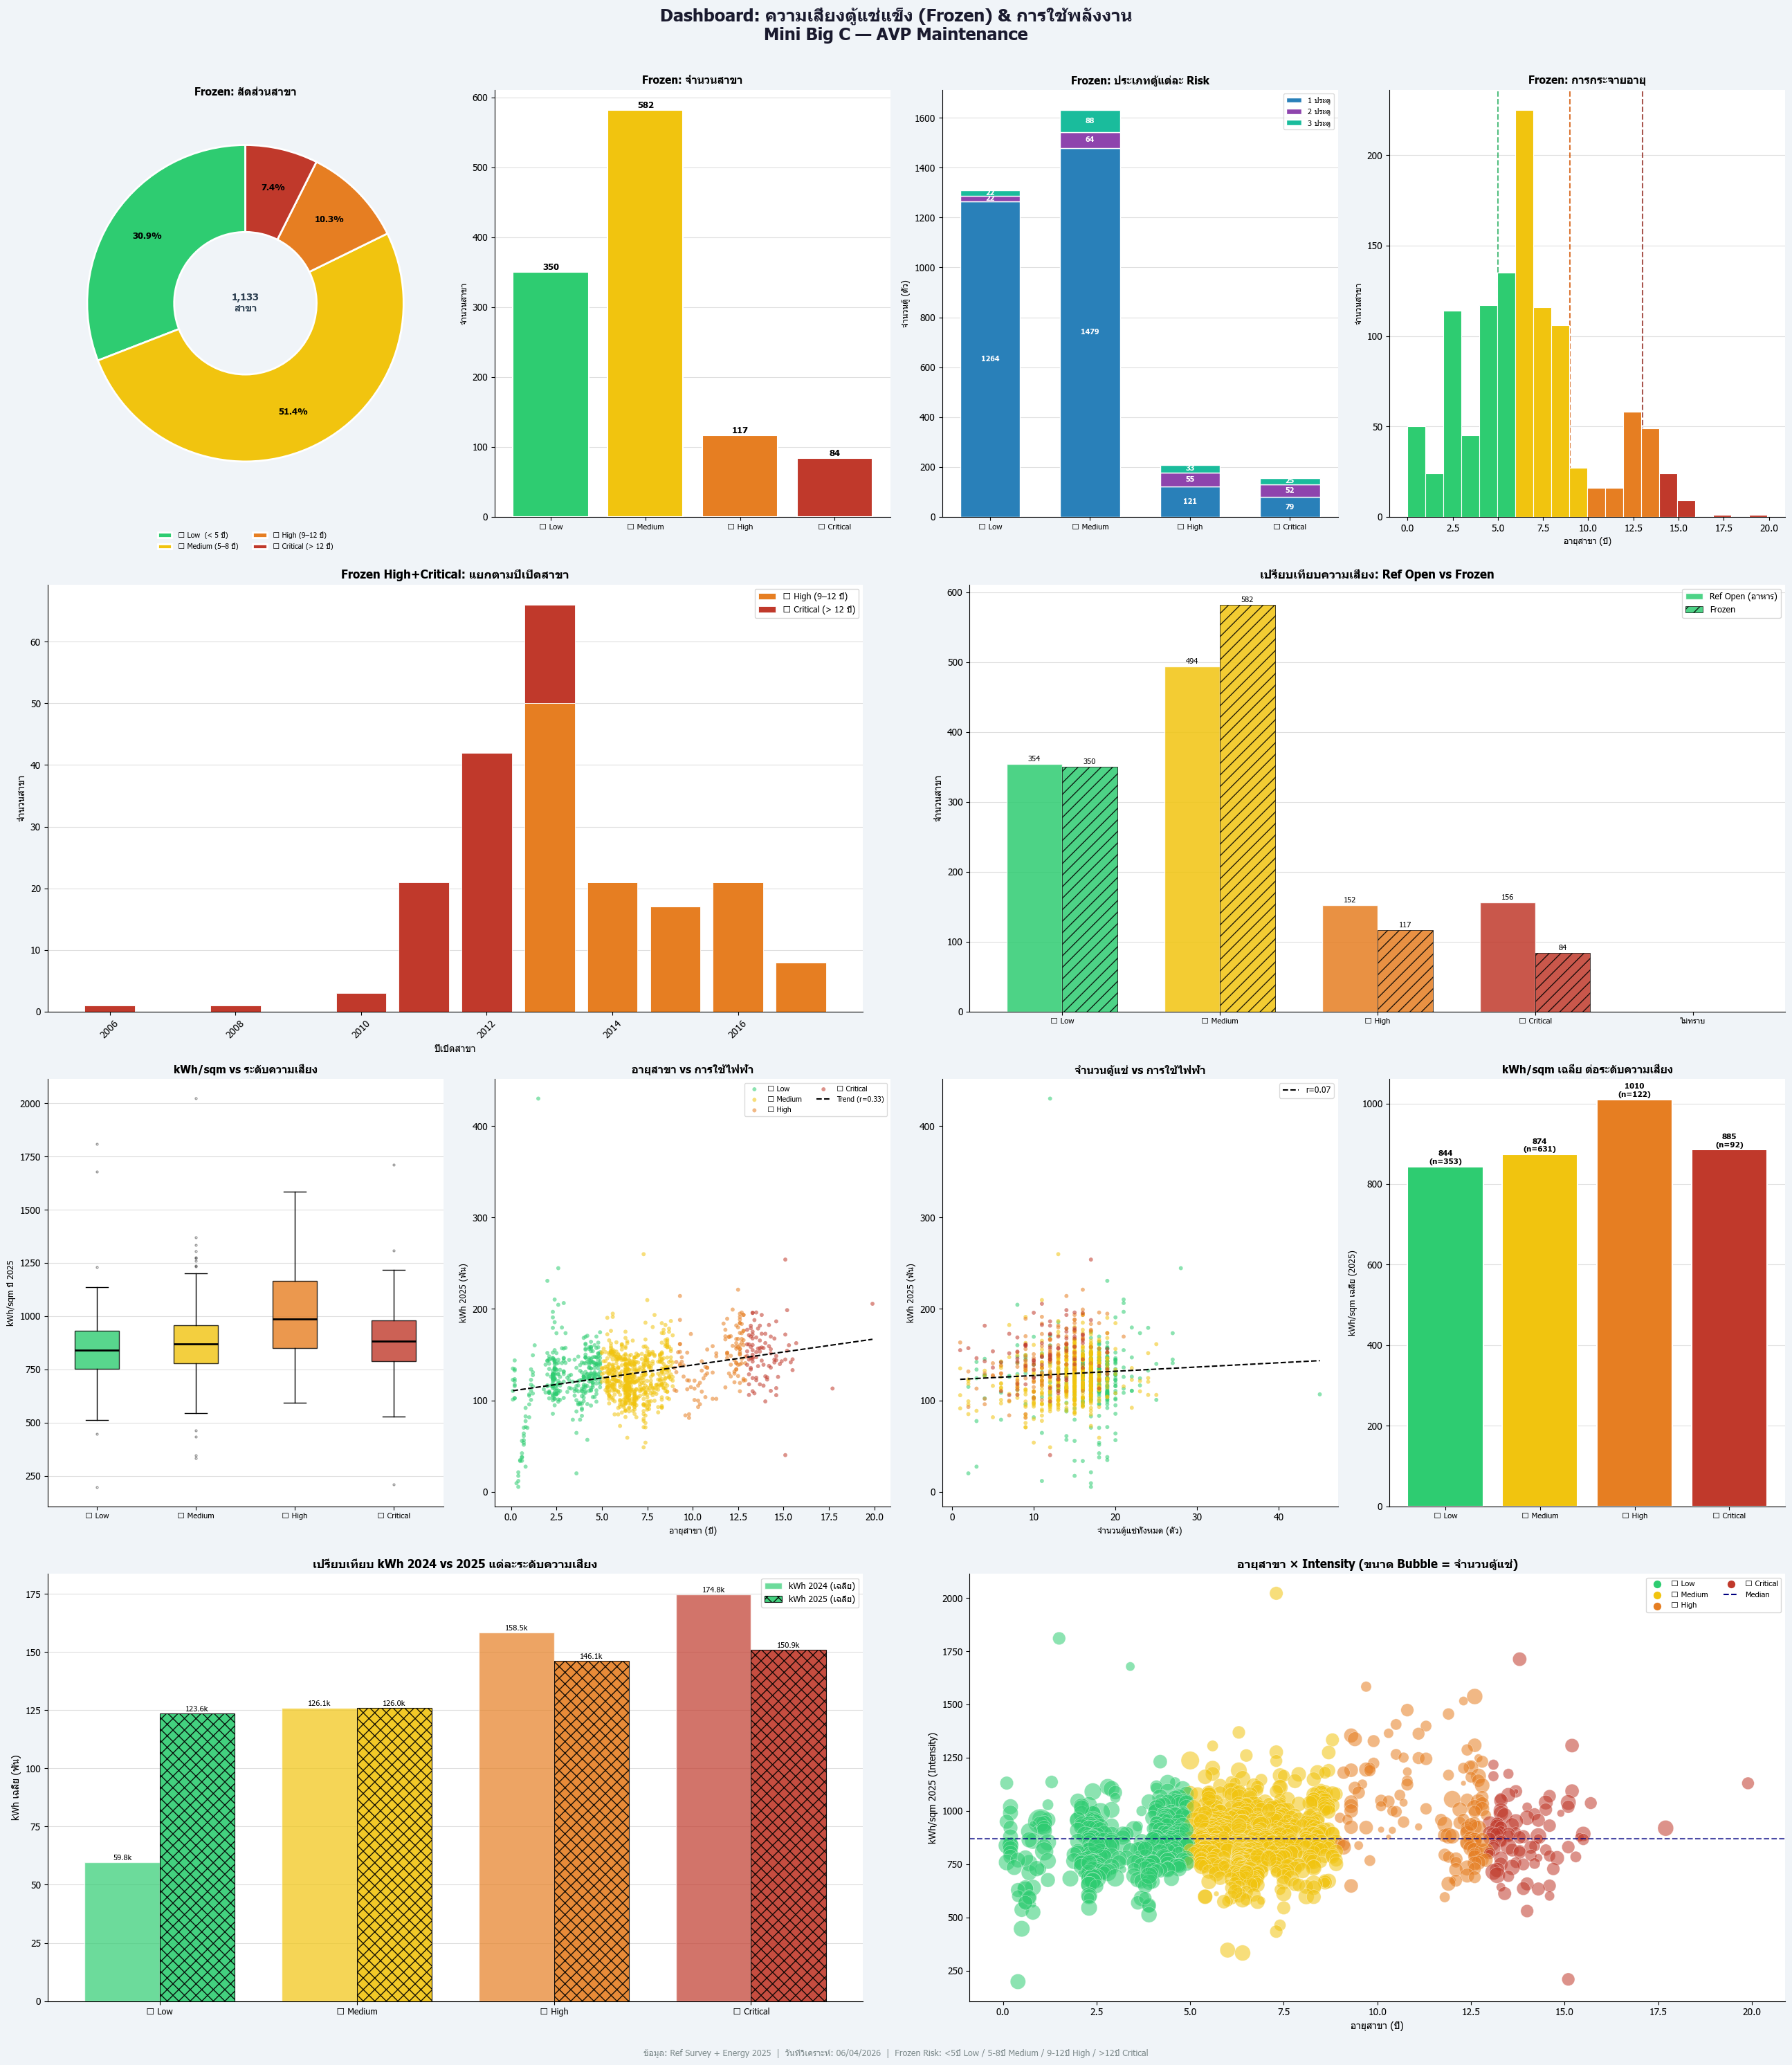

✅ Dashboard saved


In [32]:
# ═══════════════════════════════════════════════════════════════════
# PART C — COMBINED DASHBOARD  (Frozen Risk + Energy Analysis)
# ═══════════════════════════════════════════════════════════════════
F_PALETTE = [F_COLOR[k] for k in F_ORDER if k in frozen_df['Risk Key'].unique()]
F_LABELS  = [F_LABEL[k] for k in F_ORDER if k in frozen_df['Risk Key'].unique()]
valid_keys = [k for k in F_ORDER if k in frozen_df['Risk Key'].unique()]

fig = plt.figure(figsize=(26, 30), facecolor='#f0f4f8')
fig.suptitle('Dashboard: ความเสี่ยงตู้แช่แข็ง (Frozen) & การใช้พลังงาน\nMini Big C — AVP Maintenance',
             fontsize=18, fontweight='bold', y=0.99, color='#1a1a2e')

# ─── ROW 1: Frozen Risk (4 charts) ─────────────────────────────────
# [1-1] Donut — สัดส่วนสาขา
ax1 = fig.add_subplot(4, 4, 1)
wedges, texts, autotexts = ax1.pie(
    f_risk_sum['Stores'], colors=F_PALETTE, autopct='%1.1f%%',
    startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2))
for at in autotexts: at.set_fontsize(9); at.set_fontweight('bold')
ax1.legend(wedges, F_LABELS, loc='upper center', bbox_to_anchor=(0.5,-0.06), fontsize=7.5, ncol=2, frameon=False)
total_f = f_risk_sum['Stores'].sum()
ax1.text(0,0, f'{total_f:,}\nสาขา', ha='center', va='center', fontsize=10, fontweight='bold', color='#2c3e50')
ax1.set_title('Frozen: สัดส่วนสาขา', fontsize=11, fontweight='bold', pad=10)

# [1-2] Bar — จำนวนสาขา Frozen
ax2 = fig.add_subplot(4, 4, 2)
b2 = ax2.bar(range(len(f_risk_sum)), f_risk_sum['Stores'], color=F_PALETTE, edgecolor='white', linewidth=1.5, zorder=3)
for bar, v in zip(b2, f_risk_sum['Stores']):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{v:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_xticks(range(len(F_LABELS))); ax2.set_xticklabels([l.split('(')[0].strip() for l in F_LABELS], fontsize=8)
ax2.set_ylabel('จำนวนสาขา', fontsize=9); ax2.set_title('Frozen: จำนวนสาขา', fontsize=11, fontweight='bold')
ax2.yaxis.grid(True, alpha=0.4, zorder=0); ax2.set_axisbelow(True); ax2.spines[['top','right']].set_visible(False)

# [1-3] Stacked Bar — ประเภท Frozen (1D/2D/3D) ต่อ Risk
ax3 = fig.add_subplot(4, 4, 3)
x3 = range(len(f_risk_sum))
w3 = 0.6
bot = np.zeros(len(f_risk_sum))
d_cols = [('U_1D','1 ประตู','#2980b9'),('U_2D','2 ประตู','#8e44ad'),('U_3D','3 ประตู','#1abc9c')]
for col, lbl, clr in d_cols:
    v3 = f_risk_sum[col].values.astype(float)
    ax3.bar(x3, v3, bottom=bot, color=clr, width=w3, edgecolor='white', label=lbl, zorder=3)
    for xi, (bv, vv) in enumerate(zip(bot, v3)):
        if vv > 20: ax3.text(xi, bv+vv/2, str(int(vv)), ha='center', va='center', fontsize=7.5, color='white', fontweight='bold')
    bot += v3
ax3.set_xticks(x3); ax3.set_xticklabels([l.split('(')[0].strip() for l in F_LABELS], fontsize=8)
ax3.set_ylabel('จำนวนตู้ (ตัว)', fontsize=9); ax3.set_title('Frozen: ประเภทตู้แต่ละ Risk', fontsize=11, fontweight='bold')
ax3.legend(fontsize=8, framealpha=0.7); ax3.yaxis.grid(True, alpha=0.4, zorder=0); ax3.set_axisbelow(True)
ax3.spines[['top','right']].set_visible(False)

# [1-4] Histogram อายุ Frozen stores
ax4 = fig.add_subplot(4, 4, 4)
ages_f = frozen_df['Store Age (yrs)'].dropna()
n4, bins4, patches4 = ax4.hist(ages_f, bins=20, edgecolor='white', linewidth=0.8, zorder=3)
for patch, left in zip(patches4, bins4[:-1]):
    if left < 5:     patch.set_facecolor('#2ecc71')
    elif left < 9:   patch.set_facecolor('#f1c40f')
    elif left < 13:  patch.set_facecolor('#e67e22')
    else:            patch.set_facecolor('#c0392b')
ax4.axvline(5,  color='#27ae60', ls='--', lw=1.5, alpha=0.8)
ax4.axvline(9,  color='#d35400', ls='--', lw=1.5, alpha=0.8)
ax4.axvline(13, color='#922b21', ls='--', lw=1.5, alpha=0.8)
ax4.set_xlabel('อายุสาขา (ปี)', fontsize=9); ax4.set_ylabel('จำนวนสาขา', fontsize=9)
ax4.set_title('Frozen: การกระจายอายุ', fontsize=11, fontweight='bold')
ax4.yaxis.grid(True, alpha=0.4, zorder=0); ax4.set_axisbelow(True); ax4.spines[['top','right']].set_visible(False)

# ─── ROW 2: Open vs Frozen Combined Risk (2 wide charts) ───────────
# [2-1] Open Year bar (Frozen High+Critical)
ax5 = fig.add_subplot(4, 2, 3)
fhc = frozen_df[frozen_df['Risk Key'].isin(['3_High','4_Critical'])].copy()
fhc['Open Year'] = fhc['Open Year'].fillna(0).astype(int)
yr_fhc = fhc[fhc['Open Year']>2000].groupby(['Open Year','Risk Key']).size().unstack(fill_value=0)
yr_fhc = yr_fhc.reindex(columns=[k for k in F_ORDER if k in yr_fhc.columns])
bot5 = np.zeros(len(yr_fhc))
for key in yr_fhc.columns:
    ax5.bar(yr_fhc.index, yr_fhc[key], bottom=bot5, color=F_COLOR[key], edgecolor='white', lw=0.6,
            label=F_LABEL[key], zorder=3)
    bot5 += yr_fhc[key].values.astype(float)
ax5.set_title('Frozen High+Critical: แยกตามปีเปิดสาขา', fontsize=12, fontweight='bold')
ax5.set_xlabel('ปีเปิดสาขา', fontsize=10); ax5.set_ylabel('จำนวนสาขา', fontsize=10)
ax5.legend(fontsize=9, framealpha=0.8); ax5.tick_params(axis='x', rotation=45)
ax5.yaxis.grid(True, alpha=0.4, zorder=0); ax5.set_axisbelow(True); ax5.spines[['top','right']].set_visible(False)

# [2-2] Comparison: Ref Open vs Frozen Risk distribution
ax6 = fig.add_subplot(4, 2, 4)
open_risk_cnt = analysis_df['Risk Key'].value_counts().reindex(F_ORDER, fill_value=0)
froz_risk_cnt = frozen_df['Risk Key'].value_counts().reindex(F_ORDER, fill_value=0)
x6 = np.arange(len(F_ORDER))
w6 = 0.35
bars6a = ax6.bar(x6 - w6/2, open_risk_cnt.values, width=w6, color=[F_COLOR[k] for k in F_ORDER],
                 edgecolor='white', label='Ref Open (อาหาร)', zorder=3, alpha=0.85)
bars6b = ax6.bar(x6 + w6/2, froz_risk_cnt.values, width=w6, color=[F_COLOR[k] for k in F_ORDER],
                 edgecolor='black', linewidth=0.6, label='Frozen', zorder=3, hatch='//', alpha=0.85)
for b, v in zip(bars6a, open_risk_cnt.values):
    if v > 0: ax6.text(b.get_x()+b.get_width()/2, b.get_height()+2, str(v), ha='center', va='bottom', fontsize=8)
for b, v in zip(bars6b, froz_risk_cnt.values):
    if v > 0: ax6.text(b.get_x()+b.get_width()/2, b.get_height()+2, str(v), ha='center', va='bottom', fontsize=8)
ax6.set_xticks(x6); ax6.set_xticklabels([F_LABEL[k].split('(')[0].strip() for k in F_ORDER], fontsize=8)
ax6.set_ylabel('จำนวนสาขา', fontsize=10); ax6.set_title('เปรียบเทียบความเสี่ยง: Ref Open vs Frozen', fontsize=12, fontweight='bold')
ax6.legend(fontsize=9, framealpha=0.8); ax6.yaxis.grid(True, alpha=0.4, zorder=0)
ax6.set_axisbelow(True); ax6.spines[['top','right']].set_visible(False)

# ─── ROW 3: Energy Analysis ─────────────────────────────────────────
# [3-1] Box plot kWh/sqm vs Risk Level
ax7 = fig.add_subplot(4, 4, 9)
risk_groups = [energy_valid[energy_valid['Risk Key']==k]['kWh/sqm 2025'].dropna()
               for k in F_ORDER if k in energy_valid['Risk Key'].unique()]
valid_keys7  = [k for k in F_ORDER if k in energy_valid['Risk Key'].unique()]
bp = ax7.boxplot(risk_groups, patch_artist=True, notch=False, showfliers=True,
                 flierprops=dict(marker='o', markersize=2, alpha=0.4))
for patch, key in zip(bp['boxes'], valid_keys7):
    patch.set_facecolor(F_COLOR[key]); patch.set_alpha(0.8)
for med in bp['medians']: med.set(color='black', linewidth=2)
ax7.set_xticklabels([F_LABEL[k].split('(')[0].strip() for k in valid_keys7], fontsize=8)
ax7.set_ylabel('kWh/sqm ปี 2025', fontsize=9); ax7.set_title('kWh/sqm vs ระดับความเสี่ยง', fontsize=11, fontweight='bold')
ax7.yaxis.grid(True, alpha=0.4); ax7.set_axisbelow(True); ax7.spines[['top','right']].set_visible(False)

# [3-2] Scatter: Store Age vs kWh 2025
ax8 = fig.add_subplot(4, 4, 10)
for key in valid_keys7:
    sub = energy_valid[energy_valid['Risk Key']==key]
    ax8.scatter(sub['Store Age (yrs)'], sub['kWh 2025']/1000, c=F_COLOR[key],
                alpha=0.55, s=18, label=F_LABEL[key].split('(')[0].strip(), edgecolors='none')
# trend line
x_trend = energy_valid['Store Age (yrs)']
y_trend = energy_valid['kWh 2025']/1000
m, b_val, r, p, se = stats.linregress(x_trend.dropna(), y_trend[x_trend.notna()])
x_line = np.linspace(x_trend.min(), x_trend.max(), 100)
ax8.plot(x_line, m*x_line+b_val, 'k--', lw=1.5, label=f'Trend (r={r:.2f})')
ax8.set_xlabel('อายุสาขา (ปี)', fontsize=9); ax8.set_ylabel('kWh 2025 (พัน)', fontsize=9)
ax8.set_title('อายุสาขา vs การใช้ไฟฟ้า', fontsize=11, fontweight='bold')
ax8.legend(fontsize=7.5, framealpha=0.7, ncol=2); ax8.spines[['top','right']].set_visible(False)

# [3-3] Scatter: Total Ref Units vs kWh 2025
ax9 = fig.add_subplot(4, 4, 11)
for key in valid_keys7:
    sub = energy_valid[energy_valid['Risk Key']==key]
    ax9.scatter(sub['Total Ref Units'], sub['kWh 2025']/1000, c=F_COLOR[key],
                alpha=0.55, s=18, edgecolors='none')
x_t = energy_valid['Total Ref Units']
y_t = energy_valid['kWh 2025']/1000
m2, b2v, r2, p2, se2 = stats.linregress(x_t.dropna(), y_t[x_t.notna()])
x_l2 = np.linspace(x_t.min(), x_t.max(), 100)
ax9.plot(x_l2, m2*x_l2+b2v, 'k--', lw=1.5, label=f'r={r2:.2f}')
ax9.set_xlabel('จำนวนตู้แช่ทั้งหมด (ตัว)', fontsize=9); ax9.set_ylabel('kWh 2025 (พัน)', fontsize=9)
ax9.set_title('จำนวนตู้แช่ vs การใช้ไฟฟ้า', fontsize=11, fontweight='bold')
ax9.legend(fontsize=8.5, framealpha=0.7); ax9.spines[['top','right']].set_visible(False)

# [3-4] Bar: kWh/sqm เฉลี่ย ต่อ Risk Level
ax10 = fig.add_subplot(4, 4, 12)
energy_risk_avg = energy_valid.groupby('Risk Key').agg(
    avg_kwh_sqm=('kWh/sqm 2025','mean'), cnt=('Store ID','count')).reindex(valid_keys7).reset_index()
b10 = ax10.bar(range(len(energy_risk_avg)), energy_risk_avg['avg_kwh_sqm'],
               color=[F_COLOR[k] for k in energy_risk_avg['Risk Key']],
               edgecolor='white', lw=1.5, zorder=3)
for bar, v, c in zip(b10, energy_risk_avg['avg_kwh_sqm'], energy_risk_avg['cnt']):
    ax10.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
              f'{v:.0f}\n(n={c})', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax10.set_xticks(range(len(energy_risk_avg)))
ax10.set_xticklabels([F_LABEL[k].split('(')[0].strip() for k in energy_risk_avg['Risk Key']], fontsize=8)
ax10.set_ylabel('kWh/sqm เฉลี่ย (2025)', fontsize=9)
ax10.set_title('kWh/sqm เฉลี่ย ต่อระดับความเสี่ยง', fontsize=11, fontweight='bold')
ax10.yaxis.grid(True, alpha=0.4, zorder=0); ax10.set_axisbelow(True); ax10.spines[['top','right']].set_visible(False)

# ─── ROW 4: Wide Charts ──────────────────────────────────────────────
# [4-1] kWh 2024 vs 2025 per Risk (YoY trend)
ax11 = fig.add_subplot(4, 2, 7)
e_yoy = energy_valid.groupby('Risk Key').agg(
    kWh_2024=('kWh 2024','mean'), kWh_2025=('kWh 2025','mean')).reindex(valid_keys7).reset_index()
x11 = np.arange(len(e_yoy)); w11 = 0.38
b11a = ax11.bar(x11 - w11/2, e_yoy['kWh_2024']/1000, width=w11, color=[F_COLOR[k] for k in e_yoy['Risk Key']],
                edgecolor='white', label='kWh 2024 (เฉลี่ย)', alpha=0.7, zorder=3)
b11b = ax11.bar(x11 + w11/2, e_yoy['kWh_2025']/1000, width=w11, color=[F_COLOR[k] for k in e_yoy['Risk Key']],
                edgecolor='black', lw=0.8, label='kWh 2025 (เฉลี่ย)', hatch='xx', alpha=0.9, zorder=3)
for b, v in zip(b11a, e_yoy['kWh_2024']/1000):
    ax11.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f'{v:.1f}k', ha='center', va='bottom', fontsize=8)
for b, v in zip(b11b, e_yoy['kWh_2025']/1000):
    ax11.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f'{v:.1f}k', ha='center', va='bottom', fontsize=8)
ax11.set_xticks(x11); ax11.set_xticklabels([F_LABEL[k].split('(')[0].strip() for k in e_yoy['Risk Key']], fontsize=9)
ax11.set_ylabel('kWh เฉลี่ย (พัน)', fontsize=10); ax11.set_title('เปรียบเทียบ kWh 2024 vs 2025 แต่ละระดับความเสี่ยง', fontsize=12, fontweight='bold')
ax11.legend(fontsize=9, framealpha=0.8); ax11.yaxis.grid(True, alpha=0.4, zorder=0)
ax11.set_axisbelow(True); ax11.spines[['top','right']].set_visible(False)

# [4-2] Scatter: Store Age + #Units bubble → kWh/sqm intensity
ax12 = fig.add_subplot(4, 2, 8)
scatter_data = energy_valid.dropna(subset=['Store Age (yrs)','kWh/sqm 2025','Total Ref Units'])
sc = ax12.scatter(scatter_data['Store Age (yrs)'], scatter_data['kWh/sqm 2025'],
                  c=[F_COLOR[k] for k in scatter_data['Risk Key']],
                  s=scatter_data['Total Ref Units']*15, alpha=0.55, edgecolors='white', linewidths=0.4)
ax12.axhline(scatter_data['kWh/sqm 2025'].median(), color='navy', ls='--', lw=1.5, alpha=0.7,
             label=f'Median = {scatter_data["kWh/sqm 2025"].median():.0f}')
ax12.set_xlabel('อายุสาขา (ปี)', fontsize=10); ax12.set_ylabel('kWh/sqm 2025 (Intensity)', fontsize=10)
ax12.set_title('อายุสาขา × Intensity (ขนาด Bubble = จำนวนตู้แช่)', fontsize=12, fontweight='bold')
patches_legend = [plt.scatter([],[], c=F_COLOR[k], s=50, label=F_LABEL[k].split('(')[0].strip()) for k in valid_keys7]
ax12.legend(handles=patches_legend + [plt.Line2D([],[], color='navy', ls='--', label='Median')],
            fontsize=8, framealpha=0.8, ncol=2)
ax12.spines[['top','right']].set_visible(False)

fig.text(0.5, 0.003,
         f'ข้อมูล: Ref Survey + Energy 2025  |  วันที่วิเคราะห์: {TODAY.strftime("%d/%m/%Y")}  |  '
         f'Frozen Risk: <5ปี Low / 5-8ปี Medium / 9-12ปี High / >12ปี Critical',
         ha='center', fontsize=9, color='#7f8c8d', style='italic')

plt.tight_layout(rect=[0, 0.01, 1, 0.985])
DASH2 = r'G:\My Drive\00. Web Projects\Air_Ref_Servey\Pyhon ANL\Frozen_Energy_Dashboard.png'
plt.savefig(DASH2, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("✅ Dashboard saved")

In [33]:
from openpyxl import Workbook
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from openpyxl.worksheet.table import Table, TableStyleInfo
from openpyxl.drawing.image import Image as XLImage
import os

OUT_XL2 = r'G:\My Drive\00. Web Projects\Air_Ref_Servey\Pyhon ANL\Frozen_Energy_Risk_Report.xlsx'

# ── helpers ──
def xfill(h): return PatternFill("solid", fgColor=h.lstrip('#'))
BORDER = Border(left=Side(style='thin'), right=Side(style='thin'),
                top=Side(style='thin'),  bottom=Side(style='thin'))
def wcell(ws, row, col, val, fill=None, bold=False, fc='000000', size=10,
          center=False, wrap=False, nf=None, border=True):
    c = ws.cell(row=row, column=col, value=val)
    if fill: c.fill = fill
    c.font = Font(bold=bold, color=fc, size=size)
    c.alignment = Alignment(horizontal='center' if center else 'left', vertical='center', wrap_text=wrap)
    if border: c.border = BORDER
    if nf: c.number_format = nf
    return c

F_HEX2 = {'1_Low':'2ecc71','2_Medium':'f1c40f','3_High':'e67e22','4_Critical':'c0392b','Unknown':'95a5a6'}
F_FC2  = {'1_Low':'FFFFFF','2_Medium':'1a1a1a','3_High':'FFFFFF','4_Critical':'FFFFFF','Unknown':'FFFFFF'}

wb2 = Workbook()

# ══════════════════════════════════════════════════════
# Sheet 1: Dashboard image
# ══════════════════════════════════════════════════════
ws_d = wb2.active; ws_d.title = "Dashboard"
ws_d.sheet_view.showGridLines = False
if os.path.exists(DASH2):
    img2 = XLImage(DASH2)
    img2.anchor = 'A1'
    ws_d.add_image(img2)
    ws_d.column_dimensions['A'].width = 160
    ws_d.row_dimensions[1].height = 1100

# ══════════════════════════════════════════════════════
# Sheet 2: Frozen Risk Summary
# ══════════════════════════════════════════════════════
ws_fs = wb2.create_sheet("Frozen Risk Summary")
ws_fs.sheet_view.showGridLines = False
ws_fs.merge_cells("A1:I1")
wcell(ws_fs, 1, 1, f'สรุปความเสี่ยงตู้แช่แข็ง Frozen — Mini Big C  |  {TODAY.strftime("%d/%m/%Y")}',
      fill=xfill('1F4E79'), bold=True, fc='FFFFFF', size=14, center=True)
ws_fs.row_dimensions[1].height = 32

hdrs_f = ['ระดับความเสี่ยง','คำอธิบาย','สาขา','สัดส่วน%','ตู้รวม','1 ประตู','2 ประตู','3 ประตู','อายุเฉลี่ย (ปี)','Action แนะนำ']
for ci, h in enumerate(hdrs_f, 1):
    wcell(ws_fs, 2, ci, h, fill=xfill('2E75B6'), bold=True, fc='FFFFFF', size=10, center=True)
ws_fs.row_dimensions[2].height = 20

f_desc = {
    '1_Low':      'อายุ < 5 ปี — ปกติ',
    '2_Medium':   'อายุ 5–8 ปี — เฝ้าระวัง',
    '3_High':     'อายุ 9–12 ปี — ใกล้ End-of-Life',
    '4_Critical': 'อายุ > 12 ปี — เกิน EOL',
    'Unknown':    'ไม่มีข้อมูล'
}
f_actions = {
    '1_Low':      'Monitor + Survey ปีละ 1 ครั้ง',
    '2_Medium':   'Preventive Maintenance ก่อนครบ 9 ปี',
    '3_High':     'PM เร่งด่วน + วางแผน Replace ภายใน 1-2 ปี',
    '4_Critical': 'Replace ทันที — Risk ของแช่เสีย / ค่าไฟสูง',
    'Unknown':    'ตรวจสอบ Date Open Store'
}
total_fs = f_risk_sum['Stores'].sum(); total_fu = f_risk_sum['Units'].sum()
row_f = 3
for _, r in f_risk_sum.iterrows():
    k = r['Risk Key']
    fg2 = xfill(F_HEX2[k]); fc2 = F_FC2[k]
    wcell(ws_fs, row_f, 1,  r['Label'],                       fill=fg2, bold=True, fc=fc2, center=True)
    wcell(ws_fs, row_f, 2,  f_desc[k],                        fill=fg2, fc=fc2, wrap=True)
    wcell(ws_fs, row_f, 3,  r['Stores'],                      fill=fg2, bold=True, fc=fc2, center=True, nf='#,##0')
    wcell(ws_fs, row_f, 4,  round(r['Stores']/total_fs*100,1),fill=fg2, fc=fc2, center=True, nf='0.0"%"')
    wcell(ws_fs, row_f, 5,  r['Units'],                       fill=fg2, bold=True, fc=fc2, center=True, nf='#,##0')
    wcell(ws_fs, row_f, 6,  r['U_1D'],                        fill=fg2, fc=fc2, center=True, nf='#,##0')
    wcell(ws_fs, row_f, 7,  r['U_2D'],                        fill=fg2, fc=fc2, center=True, nf='#,##0')
    wcell(ws_fs, row_f, 8,  r['U_3D'],                        fill=fg2, fc=fc2, center=True, nf='#,##0')
    wcell(ws_fs, row_f, 9,  r['AvgAge'],                      fill=fg2, fc=fc2, center=True, nf='0.0')
    wcell(ws_fs, row_f, 10, f_actions[k],                     fill=fg2, fc=fc2, wrap=True)
    ws_fs.row_dimensions[row_f].height = 26
    row_f += 1
# total
for ci, v in zip(range(1,11), ['รวมทั้งหมด','',total_fs,100.0,total_fu,'','','','','']):
    wcell(ws_fs, row_f, ci, v if v!='' else None,
          fill=xfill('BDD7EE'), bold=(ci in [1,3,5]), center=(ci!=2), nf=('#,##0' if ci in [3,5] else None))
ws_fs.row_dimensions[row_f].height = 22

for ci, w in zip(range(1,11),[26,34,10,10,10,10,10,10,14,44]):
    ws_fs.column_dimensions[get_column_letter(ci)].width = w

# ══════════════════════════════════════════════════════
# Sheet 3: Energy Summary per Risk Level
# ══════════════════════════════════════════════════════
ws_en = wb2.create_sheet("Energy x Risk Summary")
ws_en.sheet_view.showGridLines = False
ws_en.merge_cells("A1:J1")
wcell(ws_en, 1, 1, f'สรุปการใช้พลังงาน vs ความเสี่ยงตู้แช่  |  {TODAY.strftime("%d/%m/%Y")}',
      fill=xfill('1F4E79'), bold=True, fc='FFFFFF', size=14, center=True)
ws_en.row_dimensions[1].height = 32

en_hdrs = ['ระดับความเสี่ยง','จำนวนสาขา (energy)','kWh 2024 เฉลี่ย',
           'kWh 2025 เฉลี่ย','YoY% เฉลี่ย','kWh/sqm เฉลี่ย',
           'kWh/sqm Median','% Critical (Intensity Status)',
           'ตู้รวมเฉลี่ย/สาขา','Frozen เฉลี่ย/สาขา']
for ci, h in enumerate(en_hdrs, 1):
    wcell(ws_en, 2, ci, h, fill=xfill('2E75B6'), bold=True, fc='FFFFFF', size=10, center=True, wrap=True)
ws_en.row_dimensions[2].height = 30

valid_risk_list = [k for k in F_ORDER if k in energy_valid['Risk Key'].unique()]
en_row = 3
for k in valid_risk_list:
    sub = energy_valid[energy_valid['Risk Key']==k]
    pct_crit = (sub['Intensity Status'].str.lower()=='high').sum() / len(sub) * 100 if len(sub)>0 else 0
    fg2 = xfill(F_HEX2[k]); fc2 = F_FC2[k]
    yoy_mean = pd.to_numeric(sub['YoY % (2024-2025)'], errors='coerce').mean()
    wcell(ws_en, en_row, 1,  F_LABEL[k],                       fill=fg2, bold=True, fc=fc2, center=True)
    wcell(ws_en, en_row, 2,  len(sub),                          fill=fg2, fc=fc2, center=True, nf='#,##0')
    wcell(ws_en, en_row, 3,  round(sub['kWh 2024'].mean(),0),   fill=fg2, fc=fc2, center=True, nf='#,##0')
    wcell(ws_en, en_row, 4,  round(sub['kWh 2025'].mean(),0),   fill=fg2, bold=True, fc=fc2, center=True, nf='#,##0')
    wcell(ws_en, en_row, 5,  round(yoy_mean,1) if pd.notna(yoy_mean) else '',
                                                                 fill=fg2, fc=fc2, center=True, nf='0.0"%"')
    wcell(ws_en, en_row, 6,  round(sub['kWh/sqm 2025'].mean(),0),fill=fg2, bold=True, fc=fc2, center=True, nf='#,##0')
    wcell(ws_en, en_row, 7,  round(sub['kWh/sqm 2025'].median(),0),fill=fg2, fc=fc2, center=True, nf='#,##0')
    wcell(ws_en, en_row, 8,  round(pct_crit,1),                 fill=fg2, fc=fc2, center=True, nf='0.0"%"')
    wcell(ws_en, en_row, 9,  round(sub['Total Ref Units'].mean(),1),fill=fg2, fc=fc2, center=True, nf='0.0')
    wcell(ws_en, en_row, 10, round(sub['Frozen Total'].mean(),1),fill=fg2, fc=fc2, center=True, nf='0.0')
    ws_en.row_dimensions[en_row].height = 26
    en_row += 1
for ci, w in zip(range(1,11),[28,16,18,18,14,16,16,22,18,18]):
    ws_en.column_dimensions[get_column_letter(ci)].width = w

# ══════════════════════════════════════════════════════
# Sheet 4: Frozen Action List (High+Critical)
# ══════════════════════════════════════════════════════
ws_fa = wb2.create_sheet("Frozen Action List")
fhc_exp = frozen_df[frozen_df['Risk Key'].isin(['3_High','4_Critical'])].copy()
fhc_exp = fhc_exp.sort_values(['Risk Key','Store Age (yrs)'], ascending=[True, False])
fa_cols = ['Branch Code','Branch Name','Store Name(th) (2)','CM Area','DM Area','Province',
           'HUB (18)','Date Open Store','Store Age (yrs)',
           'Ref Frozen1 Door Qty','Ref Frozen2 Door Qty','Ref Frozen3 Door Qty',
           'Frozen Total Qty','Risk Level']
fa_out  = fhc_exp[[c for c in fa_cols if c in fhc_exp.columns]].copy()
fa_out['Date Open Store'] = fa_out['Date Open Store'].astype(str)
fa_disp = [c for c in fa_cols if c in fa_out.columns]
fa_labels = {'Branch Code':'รหัสสาขา','Branch Name':'ชื่อสาขา','Store Name(th) (2)':'ชื่อ (Master)',
             'CM Area':'CM','DM Area':'DM','Province':'จังหวัด','HUB (18)':'HUB',
             'Date Open Store':'วันเปิด','Store Age (yrs)':'อายุ (ปี)',
             'Ref Frozen1 Door Qty':'1D','Ref Frozen2 Door Qty':'2D','Ref Frozen3 Door Qty':'3D',
             'Frozen Total Qty':'รวมตู้ Frozen','Risk Level':'ระดับความเสี่ยง'}
for ci, c in enumerate(fa_disp, 1):
    wcell(ws_fa, 1, ci, fa_labels.get(c, c), fill=xfill('1F4E79'), bold=True, fc='FFFFFF', size=10, center=True)
ws_fa.row_dimensions[1].height = 22
for ri, (_, rd) in enumerate(fa_out.iterrows(), 2):
    rl = str(rd.get('Risk Level',''))
    rf2 = xfill('FADBD8') if 'Critical' in rl else (xfill('FDEBD0') if ri%2==0 else xfill('FEF9E7'))
    for ci, c in enumerate(fa_disp, 1):
        nf = '#,##0.0' if c=='Store Age (yrs)' else ('#,##0' if 'Qty' in c else None)
        wcell(ws_fa, ri, ci, rd.get(c,''), fill=rf2, nf=nf,
              center=(c in ['Branch Code','Store Age (yrs)','Date Open Store'] or 'Qty' in c))
tref_fa = f"A1:{get_column_letter(len(fa_disp))}{len(fa_out)+1}"
tfa = Table(displayName="FrozenActionList", ref=tref_fa)
tfa.tableStyleInfo = TableStyleInfo(name="TableStyleMedium3", showRowStripes=True)
ws_fa.add_table(tfa); ws_fa.freeze_panes = "A2"
for ci, c in enumerate(fa_disp,1):
    vv = [str(fa_labels.get(c,c))] + [str(fa_out.iloc[r,ci-1]) for r in range(min(100,len(fa_out)))]
    ws_fa.column_dimensions[get_column_letter(ci)].width = min(max(len(v) for v in vv)+2, 35)

# ══════════════════════════════════════════════════════
# Sheet 5: Energy x Refig Raw Data
# ══════════════════════════════════════════════════════
ws_er = wb2.create_sheet("Energy x Refig Raw")
er_cols = ['Store ID','Site Name (Eng)','Province','DM Region','Net sqm',
           'kWh 2024','kWh 2025','kWh/sqm 2024','kWh/sqm 2025',
           'YoY % (2024-2025)','Intensity Status','YoY Status','Risk_Flag',
           'Store Age (yrs)','Total Ref Units','Frozen Total',
           'Ref Open Qty','Ref Frozen1 Door Qty','Ref Frozen2 Door Qty','Ref Frozen3 Door Qty',
           'Ref Ice Cream Qty','Ref Ice Qty','Risk Level']
er_out  = energy_ref[[c for c in er_cols if c in energy_ref.columns]].copy()
er_disp = [c for c in er_cols if c in er_out.columns]
for ci, c in enumerate(er_disp, 1):
    wcell(ws_er, 1, ci, c, fill=xfill('1F4E79'), bold=True, fc='FFFFFF', size=10, center=True)
ws_er.row_dimensions[1].height = 22
for ri, (_, rd) in enumerate(er_out.iterrows(), 2):
    rl = str(rd.get('Risk Level',''))
    if 'Critical' in rl:   rf3 = xfill('FADBD8')
    elif 'High' in rl:     rf3 = xfill('FDEBD0')
    elif 'Medium' in rl:   rf3 = xfill('FEFDE7') if ri%2==0 else None
    else:                  rf3 = xfill('EAFAF1') if ri%2==0 else None
    for ci, c in enumerate(er_disp, 1):
        val = rd.get(c,'')
        nf = ('#,##0' if any(k in c for k in ['kWh','sqm','Qty','Units','Total']) else None)
        wcell(ws_er, ri, ci, val, fill=rf3, nf=nf)
tref_er = f"A1:{get_column_letter(len(er_disp))}{len(er_out)+1}"
ter = Table(displayName="EnergyRefigRaw", ref=tref_er)
ter.tableStyleInfo = TableStyleInfo(name="TableStyleMedium6", showRowStripes=True)
ws_er.add_table(ter); ws_er.freeze_panes = "A2"
for ci, c in enumerate(er_disp,1):
    vv = [c] + [str(er_out.iloc[r,ci-1]) for r in range(min(100,len(er_out)))]
    ws_er.column_dimensions[get_column_letter(ci)].width = min(max(len(v) for v in vv)+2, 35)

# ── Save ──
wb2.save(OUT_XL2)
print(f"✅ Saved: {OUT_XL2}")
print(f"   Sheet 'Dashboard'             : รูป Dashboard")
print(f"   Sheet 'Frozen Risk Summary'   : {len(f_risk_sum)} risk levels")
print(f"   Sheet 'Energy x Risk Summary' : {len(valid_risk_list)} risk levels")
print(f"   Sheet 'Frozen Action List'    : {len(fa_out)} สาขา (High+Critical)")
print(f"   Sheet 'Energy x Refig Raw'    : {len(er_out)} สาขา × {len(er_disp)} คอลัมน์")

✅ Saved: G:\My Drive\00. Web Projects\Air_Ref_Servey\Pyhon ANL\Frozen_Energy_Risk_Report.xlsx
   Sheet 'Dashboard'             : รูป Dashboard
   Sheet 'Frozen Risk Summary'   : 4 risk levels
   Sheet 'Energy x Risk Summary' : 4 risk levels
   Sheet 'Frozen Action List'    : 201 สาขา (High+Critical)
   Sheet 'Energy x Refig Raw'    : 1582 สาขา × 22 คอลัมน์


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib import rcParams
from scipy import stats
from scipy.optimize import curve_fit
import warnings; warnings.filterwarnings('ignore')

try:
    import statsmodels.api as sm
    HAS_SM = True
except ImportError:
    HAS_SM = False

rcParams['font.family'] = 'Tahoma'
rcParams['axes.unicode_minus'] = False

# ═══════════════════════════════════════════════════════════════════
# 1.  Prepare regression dataset
#     Y  = kWh/sqm 2025  (intensity — normalised by store size)
#     X1 = Store Age (yrs)
#     Controls = จำนวนตู้แต่ละประเภท
# ═══════════════════════════════════════════════════════════════════
QTY_CTRL = ['Ref Open Qty','Ref Frozen1 Door Qty','Ref Frozen2 Door Qty',
            'Ref Frozen3 Door Qty','Ref Ice Cream Qty','Ref Ice Qty',
            'Ref Bev Plugin Qty','Ref Bev Remote Qty','Ref Ss4 Door Qty',
            'Ref Bev Walk In Qty']

reg_df = energy_valid[['Store Age (yrs)','kWh/sqm 2025','kWh 2025',
                        'Net sqm','Total Ref Units','Frozen Total',
                        'Risk Key'] + QTY_CTRL].dropna(subset=['Store Age (yrs)','kWh/sqm 2025']).copy()

# fill remaining NaN in Qty with 0
for c in QTY_CTRL:
    reg_df[c] = pd.to_numeric(reg_df[c], errors='coerce').fillna(0)

Y = reg_df['kWh/sqm 2025'].values
X_age = reg_df['Store Age (yrs)'].values
X_ctrl = reg_df[QTY_CTRL].values   # shape (n, 10)

print(f"Regression dataset: {len(reg_df)} stores")
print(f"Y (kWh/sqm): mean={Y.mean():.1f}, std={Y.std():.1f}")
print(f"Age range  : {X_age.min():.1f} – {X_age.max():.1f} ปี")

# ═══════════════════════════════════════════════════════════════════
# 2.  OLS: Partial regression of Age → kWh/sqm
#     Step a) Regress Y on controls only → residual e_Y
#     Step b) Regress Age on controls    → residual e_Age
#     Step c) Plot e_Age vs e_Y  = pure age effect
# ═══════════════════════════════════════════════════════════════════
def ols_residuals(X, y):
    """OLS residuals of y regressed on X (with intercept)."""
    Xb = np.column_stack([np.ones(len(X)), X])
    beta, *_ = np.linalg.lstsq(Xb, y, rcond=None)
    return y - Xb @ beta, beta

e_Y,   beta_ctrl_Y   = ols_residuals(X_ctrl, Y)
e_Age, beta_ctrl_Age = ols_residuals(X_ctrl, X_age)

# Partial slope of Age in full model
m_partial, b_partial, r_partial, p_partial, se_partial = stats.linregress(e_Age, e_Y)
print(f"\nPartial effect of Age on kWh/sqm (controlling for all unit counts):")
print(f"  Slope = {m_partial:.3f} kWh/sqm per year")
print(f"  r     = {r_partial:.3f}  |  p = {p_partial:.4f}")

# Full model R²
if HAS_SM:
    X_full = sm.add_constant(np.column_stack([X_age, X_ctrl]))
    model  = sm.OLS(Y, X_full).fit()
    print(f"\nFull OLS model  R² = {model.rsquared:.3f}  |  adj-R² = {model.rsquared_adj:.3f}")
    print(model.summary().tables[1])

Regression dataset: 1198 stores
Y (kWh/sqm): mean=879.6, std=166.4
Age range  : 0.1 – 19.9 ปี

Partial effect of Age on kWh/sqm (controlling for all unit counts):
  Slope = 7.963 kWh/sqm per year
  r     = 0.133  |  p = 0.0000

Full OLS model  R² = 0.058  |  adj-R² = 0.049
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        865.0540     25.419     34.031      0.000     815.182     914.926
x1             7.9628      1.717      4.637      0.000       4.593      11.332
x2            -3.9164      2.629     -1.489      0.137      -9.075       1.243
x3            -8.9891      4.411     -2.038      0.042     -17.644      -0.335
x4           -25.0417     10.527     -2.379      0.018     -45.696      -4.387
x5            14.2370     12.336      1.154      0.249      -9.966      38.440
x6            -8.5031      7.040     -1.208      0.227     -22.316       5.310
x7             

In [36]:
# ═══════════════════════════════════════════════════════════════════
# 3.  Helper: Polynomial fit + 95% Confidence Band
# ═══════════════════════════════════════════════════════════════════
def poly_fit_ci(x, y, deg=2, n_pts=200, ci=0.95):
    """Fit polynomial, return x_line, y_fit, y_lo, y_hi."""
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    n = len(x)
    coeffs = np.polyfit(x, y, deg)
    p_fn   = np.poly1d(coeffs)
    x_line = np.linspace(x.min(), x.max(), n_pts)
    y_fit  = p_fn(x_line)

    # Residual std → t-based CI
    y_pred_all = p_fn(x)
    residuals  = y - y_pred_all
    s2 = np.sum(residuals**2) / (n - deg - 1)

    # Vandermonde for CI
    V  = np.vander(x, deg+1)
    cov = np.linalg.inv(V.T @ V) * s2
    V_new = np.vander(x_line, deg+1)
    var_fit = np.einsum('ij,jk,ik->i', V_new, cov, V_new)
    t_val   = t_dist.ppf((1+ci)/2, df=n-deg-1)
    margin  = t_val * np.sqrt(var_fit)
    r_val   = np.corrcoef(x, y)[0,1]
    return x_line, y_fit, y_fit-margin, y_fit+margin, r_val, coeffs

def exp_fit(x, a, b, c):
    return a * np.exp(b * x) + c

# ═══════════════════════════════════════════════════════════════════
# 4.  Stratify stores by Total Ref Units bins
#     (เทียบสาขาที่มีตู้แช่ปริมาณใกล้เคียงกัน)
# ═══════════════════════════════════════════════════════════════════
# bin by total units: 1-5 / 6-10 / 11-15 / 16+
bins_units = [0, 5, 10, 15, 100]
bin_labels = ['1–5 ตัว','6–10 ตัว','11–15 ตัว','16+ ตัว']
bin_colors = ['#2196F3','#4CAF50','#FF9800','#E91E63']
reg_df['Units Bin'] = pd.cut(reg_df['Total Ref Units'], bins=bins_units,
                              labels=bin_labels, right=True)

# also bin by Frozen count
bins_frozen = [-1, 0, 3, 6, 100]
frozen_labels = ['ไม่มี Frozen','Frozen 1–3','Frozen 4–6','Frozen 7+']
frozen_colors = ['#78909C','#42A5F5','#AB47BC','#EF5350']
reg_df['Frozen Bin'] = pd.cut(reg_df['Frozen Total'], bins=bins_frozen,
                               labels=frozen_labels, right=True)

# ═══════════════════════════════════════════════════════════════════
# 5.  Predicted kWh/sqm vs Age for "Standard Store" scenarios
#     using full OLS model (hold qty at fixed values)
# ═══════════════════════════════════════════════════════════════════
# Scenario: mean qty profile (= typical Mini Big C)
qty_mean = reg_df[QTY_CTRL].mean().values
qty_p25  = reg_df[QTY_CTRL].quantile(0.25).values
qty_p75  = reg_df[QTY_CTRL].quantile(0.75).values

if HAS_SM:
    age_range = np.linspace(0.5, 20, 100)
    scenario_labels = [
        ('สาขาทั่วไป (mean qty)',    qty_mean,  '#2E75B6', '-'),
        ('สาขาตู้น้อย (Q1 qty)',     qty_p25,   '#2ecc71', '--'),
        ('สาขาตู้มาก (Q3 qty)',     qty_p75,   '#e74c3c', '--'),
    ]
    pred_scenarios = []
    for lbl, qtys, col, ls in scenario_labels:
        X_pred = np.column_stack([
            np.ones(len(age_range)),
            age_range,
            np.tile(qtys, (len(age_range),1))
        ])
        pred_y = X_pred @ model.params
        se_pred = np.sqrt(np.einsum('ij,jk,ik->i', X_pred, model.cov_params(), X_pred))
        t95 = t_dist.ppf(0.975, df=model.df_resid)
        pred_scenarios.append((lbl, age_range, pred_y, pred_y-t95*se_pred, pred_y+t95*se_pred, col, ls))

print("Scenarios prepared:", len(pred_scenarios))
for p in pred_scenarios:
    print(f"  {p[0]}: age=1yr → {p[2][0]:.1f}, age=10yr → {p[2][int(9/20*100)]:.1f}, age=20yr → {p[2][-1]:.1f} kWh/sqm")

Scenarios prepared: 3
  สาขาทั่วไป (mean qty): age=1yr → 830.1, age=10yr → 900.7, age=20yr → 985.4 kWh/sqm
  สาขาตู้น้อย (Q1 qty): age=1yr → 831.4, age=10yr → 902.0, age=20yr → 986.7 kWh/sqm
  สาขาตู้มาก (Q3 qty): age=1yr → 825.5, age=10yr → 896.1, age=20yr → 980.8 kWh/sqm


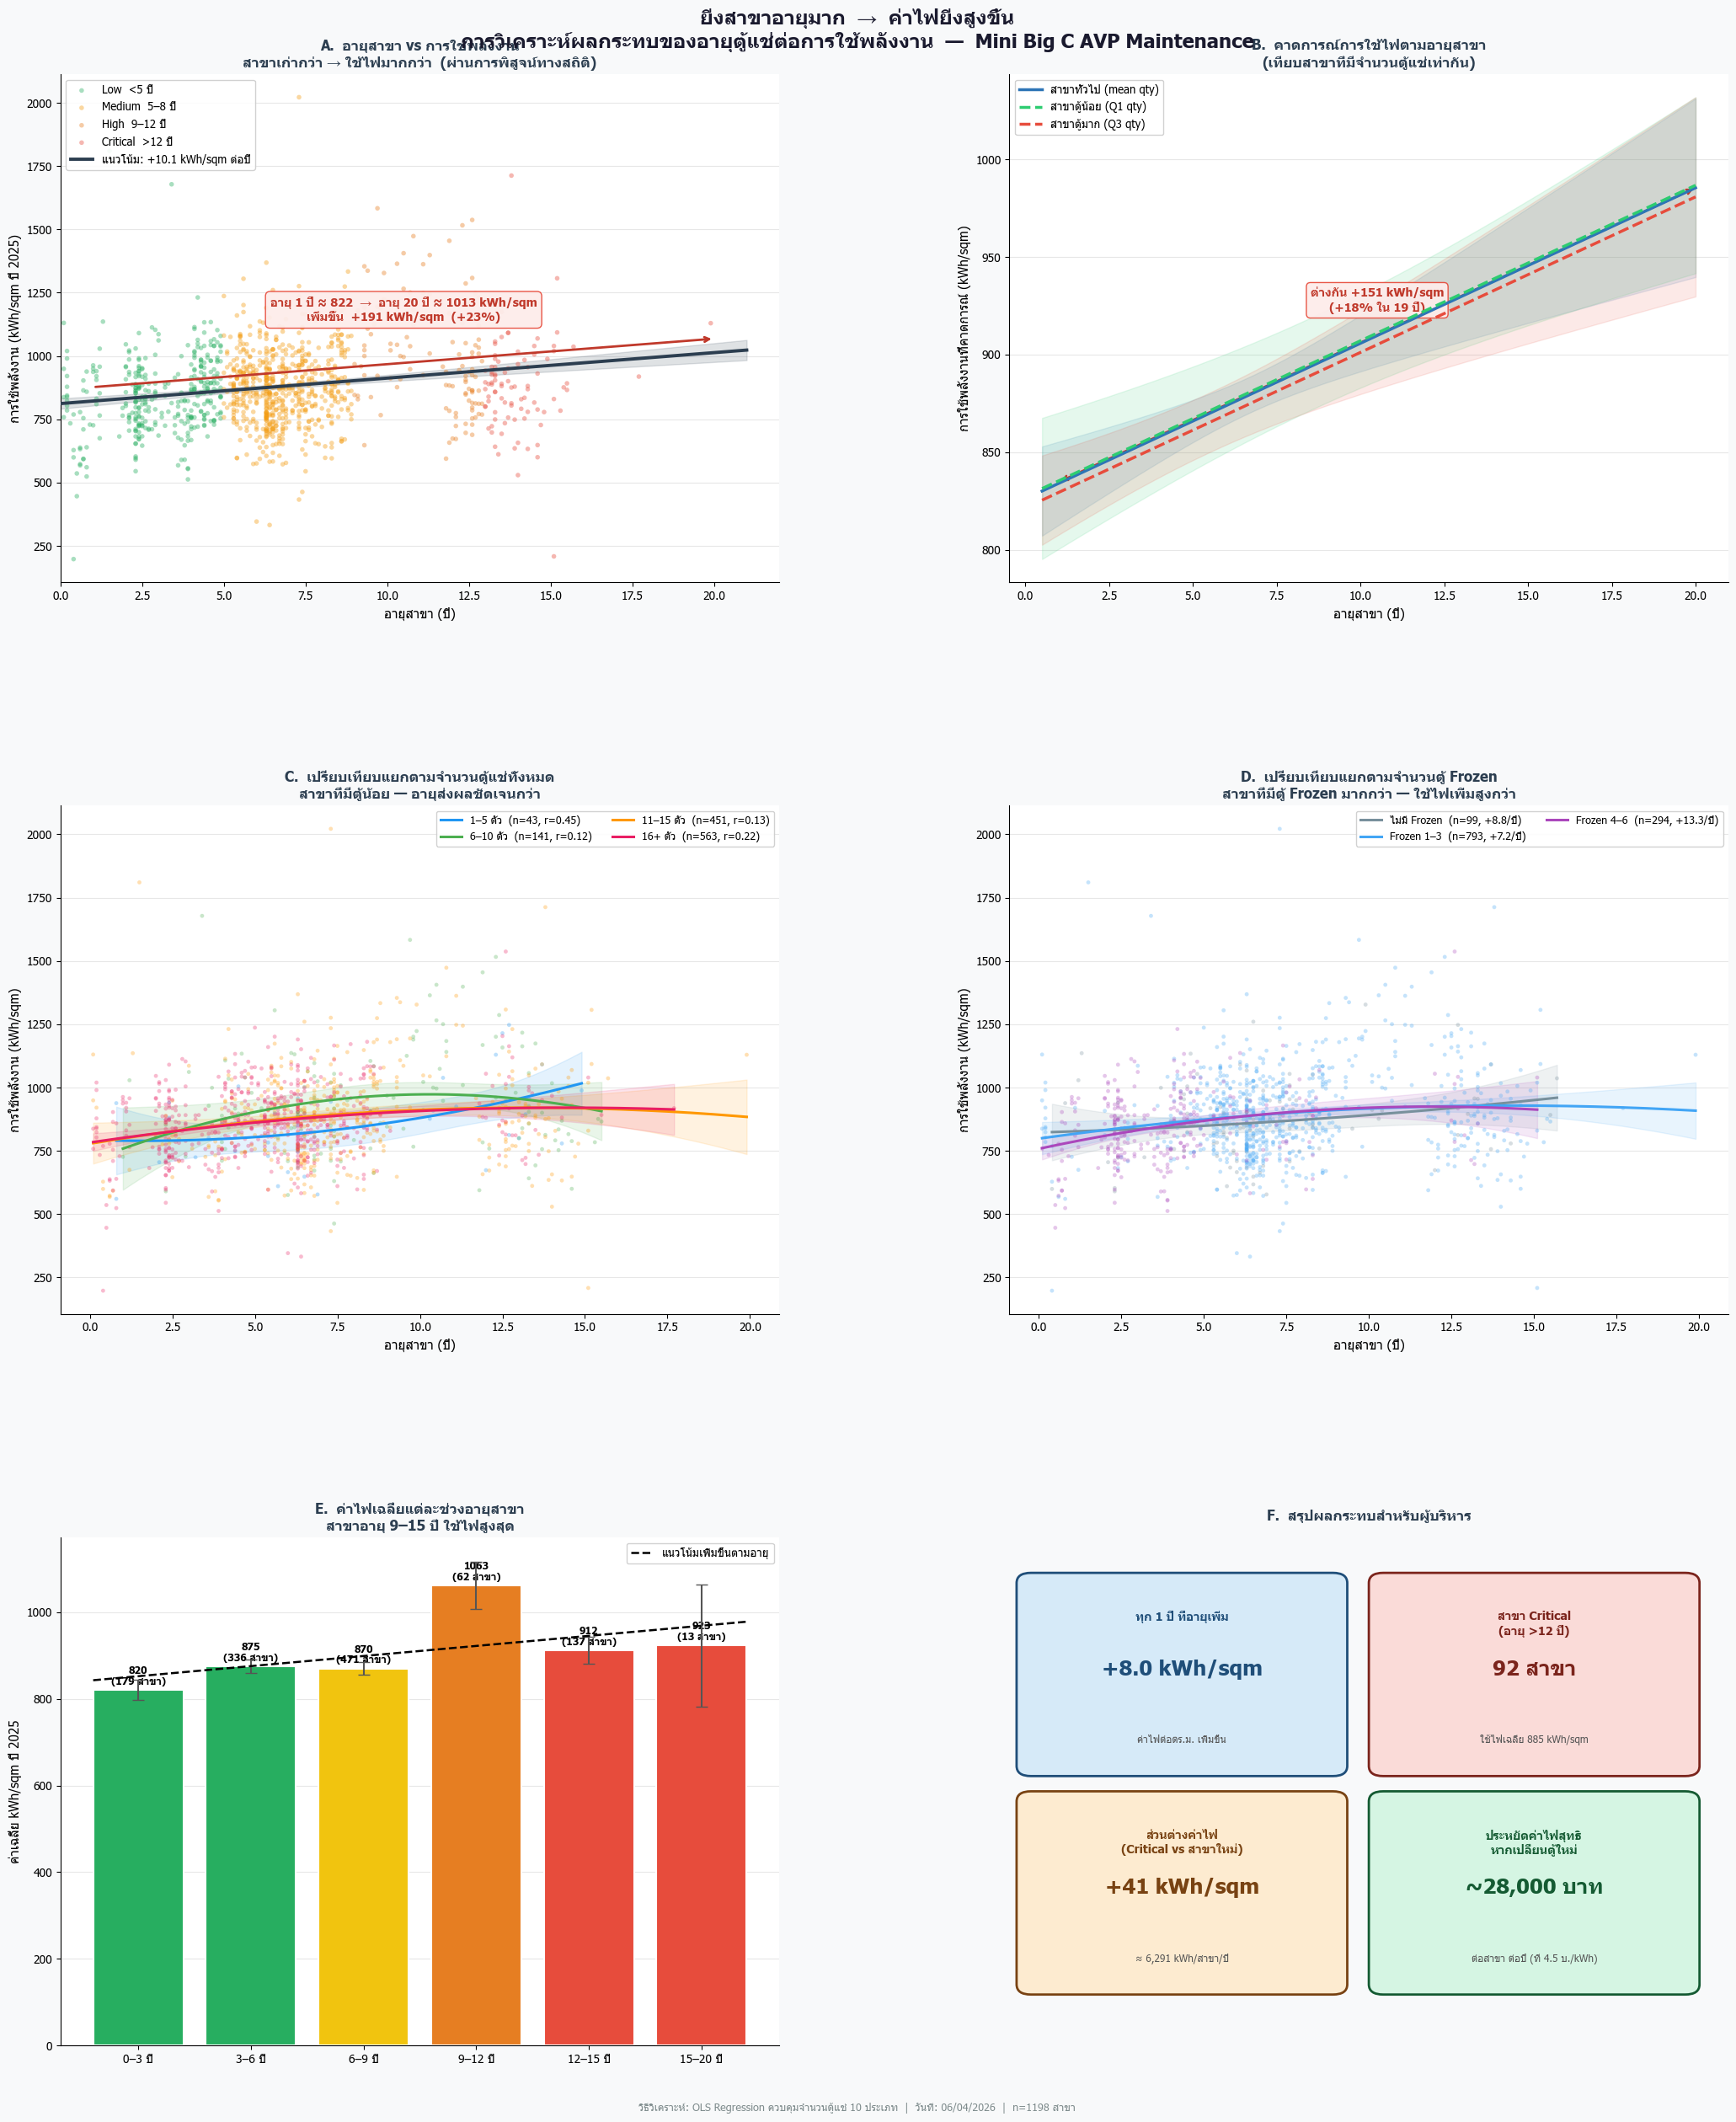

✅ Saved: G:\My Drive\00. Web Projects\Air_Ref_Servey\Pyhon ANL\Age_Energy_FitCurve.png

  ทุก 1 ปี → +8.0 kWh/sqm  |  Critical: 92 สาขา
  ประหยัดได้ ~28,311 บาท/สาขา/ปี หากเปลี่ยนตู้แช่


In [38]:
# ═══════════════════════════════════════════════════════════════════
# 6.  EXECUTIVE DASHBOARD — อายุตู้แช่ vs การใช้พลังงาน
# ═══════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(22, 26), facecolor='#f8f9fa')
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.44, wspace=0.32,
                        left=0.07, right=0.97, top=0.94, bottom=0.04)

fig.suptitle(
    'ยิ่งสาขาอายุมาก  →  ค่าไฟยิ่งสูงขึ้น\n'
    'การวิเคราะห์ผลกระทบของอายุตู้แช่ต่อการใช้พลังงาน  —  Mini Big C AVP Maintenance',
    fontsize=17, fontweight='bold', color='#1a1a2e', y=0.97)

GRAY = '#bdc3c7'; DARK = '#2c3e50'
RISK_COLOR_EXEC = {'1_Low': '#27ae60', '2_Medium': '#f39c12',
                   '3_High': '#e67e22', '4_Critical': '#e74c3c'}
RISK_LABEL_EXEC = {'1_Low': 'Low  <5 ปี', '2_Medium': 'Medium  5–8 ปี',
                   '3_High':  'High  9–12 ปี', '4_Critical': 'Critical  >12 ปี'}

# pre-compute numbers used across panels
crit_mean  = energy_valid[energy_valid['Risk Key']=='4_Critical']['kWh/sqm 2025'].mean()
low_mean   = energy_valid[energy_valid['Risk Key']=='1_Low']['kWh/sqm 2025'].mean()
diff_kwh   = crit_mean - low_mean
avg_sqm    = energy_valid['Net sqm'].mean()
kwh_price  = 4.5
saving_yr  = diff_kwh * avg_sqm * kwh_price
n_crit     = (reg_df['Risk Key'] == '4_Critical').sum()

# ── [A] อายุจริง vs kWh/sqm — สีตาม Risk Level ────────────────────
ax_A = fig.add_subplot(gs[0, 0])

for rk in ['1_Low','2_Medium','3_High','4_Critical']:
    sub_a = reg_df[reg_df['Risk Key'] == rk].dropna(subset=['Store Age (yrs)','kWh/sqm 2025'])
    ax_A.scatter(sub_a['Store Age (yrs)'], sub_a['kWh/sqm 2025'],
                 c=RISK_COLOR_EXEC[rk], alpha=0.4, s=16, edgecolors='none',
                 label=RISK_LABEL_EXEC[rk], zorder=2)

# Overall regression line
x_a  = reg_df.dropna(subset=['Store Age (yrs)','kWh/sqm 2025'])['Store Age (yrs)'].values
y_a  = reg_df.dropna(subset=['Store Age (yrs)','kWh/sqm 2025'])['kWh/sqm 2025'].values
xl_a = np.linspace(0, 21, 200)
m_a, b_a, *_ = stats.linregress(x_a, y_a)
ax_A.plot(xl_a, m_a*xl_a + b_a, color='#2c3e50', lw=2.8, zorder=6,
          label=f'แนวโน้ม: +{m_a:.1f} kWh/sqm ต่อปี')

# CI band
n_a = len(x_a); s_a = np.sqrt(np.sum((y_a - (m_a*x_a+b_a))**2) / (n_a-2))
var_a = s_a**2 * (1/n_a + (xl_a - x_a.mean())**2 / np.sum((x_a - x_a.mean())**2))
t95_a = t_dist.ppf(0.975, df=n_a-2)
ax_A.fill_between(xl_a, m_a*xl_a+b_a - t95_a*np.sqrt(var_a),
                  m_a*xl_a+b_a + t95_a*np.sqrt(var_a),
                  alpha=0.15, color='#2c3e50')

# Callout annotation
y_at1  = m_a*1  + b_a
y_at20 = m_a*20 + b_a
ax_A.annotate('', xy=(20, y_at20+55), xytext=(1, y_at1+55),
              arrowprops=dict(arrowstyle='->', color='#c0392b', lw=2.0))
ax_A.text(10.5, max(y_at1, y_at20) + 125,
          f'อายุ 1 ปี ≈ {y_at1:.0f}  →  อายุ 20 ปี ≈ {y_at20:.0f} kWh/sqm\n'
          f'เพิ่มขึ้น  +{y_at20-y_at1:.0f} kWh/sqm  (+{(y_at20-y_at1)/y_at1*100:.0f}%)',
          ha='center', fontsize=10, color='#c0392b', fontweight='bold',
          bbox=dict(boxstyle='round,pad=0.4', facecolor='#fdecea', edgecolor='#e74c3c', alpha=0.95))

ax_A.set_xlabel('อายุสาขา (ปี)', fontsize=11)
ax_A.set_ylabel('การใช้พลังงาน (kWh/sqm ปี 2025)', fontsize=11)
ax_A.set_title('A.  อายุสาขา vs การใช้พลังงาน\nสาขาเก่ากว่า → ใช้ไฟมากกว่า  (ผ่านการพิสูจน์ทางสถิติ)',
               fontsize=12, fontweight='bold', color=DARK)
ax_A.legend(fontsize=9.5, framealpha=0.9, loc='upper left')
ax_A.set_xlim(0, 22); ax_A.yaxis.grid(True, alpha=0.3); ax_A.set_axisbelow(True)
ax_A.spines[['top','right']].set_visible(False)

# ── [B] Predicted kWh/sqm vs Age (Scenario Lines + CI) ─────────────
ax_B = fig.add_subplot(gs[0, 1])
for lbl, ages_sc, pred_y, lo, hi, col, ls in pred_scenarios:
    ax_B.plot(ages_sc, pred_y, color=col, lw=2.5, ls=ls, label=lbl, zorder=5)
    ax_B.fill_between(ages_sc, lo, hi, color=col, alpha=0.12, zorder=2)

age1_idx  = np.argmin(np.abs(pred_scenarios[0][1] - 1))
age20_idx = np.argmin(np.abs(pred_scenarios[0][1] - 20))
y1  = pred_scenarios[0][2][age1_idx]
y20 = pred_scenarios[0][2][age20_idx]
ax_B.annotate('', xy=(20, y20), xytext=(1, y1),
              arrowprops=dict(arrowstyle='<->', color='#c0392b', lw=1.8))
ax_B.text(10.5, (y1+y20)/2 + 12,
          f'ต่างกัน +{y20-y1:.0f} kWh/sqm\n(+{(y20-y1)/y1*100:.0f}% ใน 19 ปี)',
          ha='center', fontsize=10, color='#c0392b', fontweight='bold',
          bbox=dict(boxstyle='round,pad=0.35', facecolor='#fdecea', edgecolor='#e74c3c', alpha=0.95))
ax_B.set_xlabel('อายุสาขา (ปี)', fontsize=11)
ax_B.set_ylabel('การใช้พลังงานที่คาดการณ์ (kWh/sqm)', fontsize=11)
ax_B.set_title('B.  คาดการณ์การใช้ไฟตามอายุสาขา\n(เทียบสาขาที่มีจำนวนตู้แช่เท่ากัน)',
               fontsize=12, fontweight='bold', color=DARK)
ax_B.legend(fontsize=9.5, framealpha=0.9)
ax_B.yaxis.grid(True, alpha=0.3); ax_B.set_axisbelow(True)
ax_B.spines[['top','right']].set_visible(False)

# ── [C] Stratified by Units Bin ────────────────────────────────────
ax_C = fig.add_subplot(gs[1, 0])
for bin_lbl, col in zip(bin_labels, bin_colors):
    sub = reg_df[reg_df['Units Bin'] == bin_lbl].dropna(subset=['Store Age (yrs)','kWh/sqm 2025'])
    if len(sub) < 20: continue
    x_s = sub['Store Age (yrs)'].values; y_s = sub['kWh/sqm 2025'].values
    ax_C.scatter(x_s, y_s, c=col, alpha=0.3, s=12, edgecolors='none', zorder=2)
    try:
        xl, yf, ylo, yhi, r_s, _ = poly_fit_ci(x_s, y_s, deg=2)
        ax_C.plot(xl, yf, color=col, lw=2.2, zorder=5,
                  label=f'{bin_lbl}  (n={len(sub)}, r={r_s:.2f})')
        ax_C.fill_between(xl, ylo, yhi, color=col, alpha=0.12)
    except Exception:
        pass
ax_C.set_xlabel('อายุสาขา (ปี)', fontsize=11)
ax_C.set_ylabel('การใช้พลังงาน (kWh/sqm)', fontsize=11)
ax_C.set_title('C.  เปรียบเทียบแยกตามจำนวนตู้แช่ทั้งหมด\nสาขาที่มีตู้น้อย — อายุส่งผลชัดเจนกว่า',
               fontsize=12, fontweight='bold', color=DARK)
ax_C.legend(fontsize=9, framealpha=0.9, ncol=2)
ax_C.yaxis.grid(True, alpha=0.3); ax_C.set_axisbelow(True)
ax_C.spines[['top','right']].set_visible(False)

# ── [D] Stratified by Frozen Bin ───────────────────────────────────
ax_D = fig.add_subplot(gs[1, 1])
for bin_lbl, col in zip(frozen_labels, frozen_colors):
    sub = reg_df[reg_df['Frozen Bin'] == bin_lbl].dropna(subset=['Store Age (yrs)','kWh/sqm 2025'])
    if len(sub) < 20: continue
    x_s = sub['Store Age (yrs)'].values; y_s = sub['kWh/sqm 2025'].values
    ax_D.scatter(x_s, y_s, c=col, alpha=0.3, s=12, edgecolors='none', zorder=2)
    try:
        xl, yf, ylo, yhi, r_s, _ = poly_fit_ci(x_s, y_s, deg=2)
        m_s, *_ = stats.linregress(x_s, y_s)
        ax_D.plot(xl, yf, color=col, lw=2.2, zorder=5,
                  label=f'{bin_lbl}  (n={len(sub)}, +{m_s:.1f}/ปี)')
        ax_D.fill_between(xl, ylo, yhi, color=col, alpha=0.12)
    except Exception:
        pass
ax_D.set_xlabel('อายุสาขา (ปี)', fontsize=11)
ax_D.set_ylabel('การใช้พลังงาน (kWh/sqm)', fontsize=11)
ax_D.set_title('D.  เปรียบเทียบแยกตามจำนวนตู้ Frozen\nสาขาที่มีตู้ Frozen มากกว่า — ใช้ไฟเพิ่มสูงกว่า',
               fontsize=12, fontweight='bold', color=DARK)
ax_D.legend(fontsize=9, framealpha=0.9, ncol=2)
ax_D.yaxis.grid(True, alpha=0.3); ax_D.set_axisbelow(True)
ax_D.spines[['top','right']].set_visible(False)

# ── [E] Age Bin × Mean kWh/sqm ────────────────────────────────────
ax_E = fig.add_subplot(gs[2, 0])
age_bins = [0, 3, 6, 9, 12, 15, 20]
age_bin_labels = ['0–3','3–6','6–9','9–12','12–15','15–20']
reg_df['Age Bin'] = pd.cut(reg_df['Store Age (yrs)'], bins=age_bins, labels=age_bin_labels, right=True)

age_grp = (reg_df.groupby('Age Bin', observed=True)['kWh/sqm 2025']
           .agg(['mean','std','count']).reset_index())
age_grp['se'] = age_grp['std'] / np.sqrt(age_grp['count'])
age_grp = age_grp.dropna(subset=['mean'])

age_mid = np.arange(len(age_grp))
bar_colors_E = []
for lbl in age_grp['Age Bin']:
    mid = (age_bins[age_bin_labels.index(lbl)] + age_bins[age_bin_labels.index(lbl)+1]) / 2
    if mid < 5:    bar_colors_E.append('#27ae60')
    elif mid < 9:  bar_colors_E.append('#f1c40f')
    elif mid < 13: bar_colors_E.append('#e67e22')
    else:          bar_colors_E.append('#e74c3c')

bars_E = ax_E.bar(age_mid, age_grp['mean'], color=bar_colors_E,
                  edgecolor='white', linewidth=1.5, zorder=3)
ax_E.errorbar(age_mid, age_grp['mean'], yerr=1.96*age_grp['se'],
              fmt='none', color='#555', capsize=5, linewidth=1.5, zorder=5)
for bar, row in zip(bars_E, age_grp.itertuples()):
    ax_E.text(bar.get_x()+bar.get_width()/2, bar.get_height()+8,
              f'{row.mean:.0f}\n({row.count} สาขา)', ha='center', va='bottom',
              fontsize=8.5, fontweight='bold')

mx, my = age_mid.astype(float), age_grp['mean'].values
mslope, mintercept, *_ = stats.linregress(mx, my)
ax_E.plot(np.linspace(-0.4, len(age_grp)-0.6, 100),
          mslope*np.linspace(-0.4, len(age_grp)-0.6, 100)+mintercept,
          'k--', lw=1.8, label='แนวโน้มเพิ่มขึ้นตามอายุ', zorder=6)
ax_E.set_xticks(age_mid)
ax_E.set_xticklabels([f'{lb} ปี' for lb in age_grp['Age Bin']], fontsize=10)
ax_E.set_ylabel('ค่าเฉลี่ย kWh/sqm ปี 2025', fontsize=11)
ax_E.set_title('E.  ค่าไฟเฉลี่ยแต่ละช่วงอายุสาขา\nสาขาอายุ 9–15 ปี ใช้ไฟสูงสุด',
               fontsize=12, fontweight='bold', color=DARK)
ax_E.legend(fontsize=9.5, framealpha=0.9)
ax_E.yaxis.grid(True, alpha=0.3); ax_E.set_axisbelow(True)
ax_E.spines[['top','right']].set_visible(False)

# ── [F] Executive KPI Summary — 4 Big Boxes ───────────────────────
ax_F = fig.add_subplot(gs[2, 1])
ax_F.axis('off')
ax_F.set_title('F.  สรุปผลกระทบสำหรับผู้บริหาร',
               fontsize=12, fontweight='bold', color=DARK, pad=14)

kpi_boxes = [
    ('ทุก 1 ปี ที่อายุเพิ่ม',
     f'+{m_partial:.1f} kWh/sqm',
     'ค่าไฟต่อตร.ม. เพิ่มขึ้น',
     '#1F4E79', '#D6EAF8'),
    (f'สาขา Critical\n(อายุ >12 ปี)',
     f'{n_crit} สาขา',
     f'ใช้ไฟเฉลี่ย {crit_mean:.0f} kWh/sqm',
     '#7B241C', '#FADBD8'),
    ('ส่วนต่างค่าไฟ\n(Critical vs สาขาใหม่)',
     f'+{diff_kwh:.0f} kWh/sqm',
     f'≈ {diff_kwh*avg_sqm:,.0f} kWh/สาขา/ปี',
     '#784212', '#FDEBD0'),
    ('ประหยัดค่าไฟสุทธิ\nหากเปลี่ยนตู้ใหม่',
     f'~{saving_yr/1000:.0f},000 บาท',
     'ต่อสาขา ต่อปี (ที่ 4.5 บ./kWh)',
     '#145A32', '#D5F5E3'),
]

box_w = 0.42; box_h = 0.36
positions = [(0.03, 0.55), (0.52, 0.55), (0.03, 0.12), (0.52, 0.12)]
for (bx, by), (title, value, sub_txt, hdr_col, bg_col) in zip(positions, kpi_boxes):
    rect = mpatches.FancyBboxPatch(
        (bx, by), box_w, box_h, boxstyle='round,pad=0.02',
        facecolor=bg_col, edgecolor=hdr_col, linewidth=2,
        transform=ax_F.transAxes, zorder=3)
    ax_F.add_patch(rect)
    ax_F.text(bx + box_w/2, by + box_h - 0.055, title,
              ha='center', va='top', fontsize=10, color=hdr_col,
              fontweight='bold', transform=ax_F.transAxes)
    ax_F.text(bx + box_w/2, by + box_h/2 + 0.01, value,
              ha='center', va='center', fontsize=18, color=hdr_col,
              fontweight='bold', transform=ax_F.transAxes)
    ax_F.text(bx + box_w/2, by + 0.04, sub_txt,
              ha='center', va='bottom', fontsize=8.5, color='#555',
              transform=ax_F.transAxes)

fig.text(0.5, 0.01,
    f'วิธีวิเคราะห์: OLS Regression ควบคุมจำนวนตู้แช่ 10 ประเภท  |  '
    f'วันที่: {TODAY.strftime("%d/%m/%Y")}  |  n={len(reg_df)} สาขา',
    ha='center', fontsize=9, color='#7f8c8d', style='italic')

DASH3 = r'G:\My Drive\00. Web Projects\Air_Ref_Servey\Pyhon ANL\Age_Energy_FitCurve.png'
plt.savefig(DASH3, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f"✅ Saved: {DASH3}")
print(f"\n{'='*60}")
print(f"  ทุก 1 ปี → +{m_partial:.1f} kWh/sqm  |  Critical: {n_crit} สาขา")
print(f"  ประหยัดได้ ~{saving_yr:,.0f} บาท/สาขา/ปี หากเปลี่ยนตู้แช่")
print(f"{'='*60}")

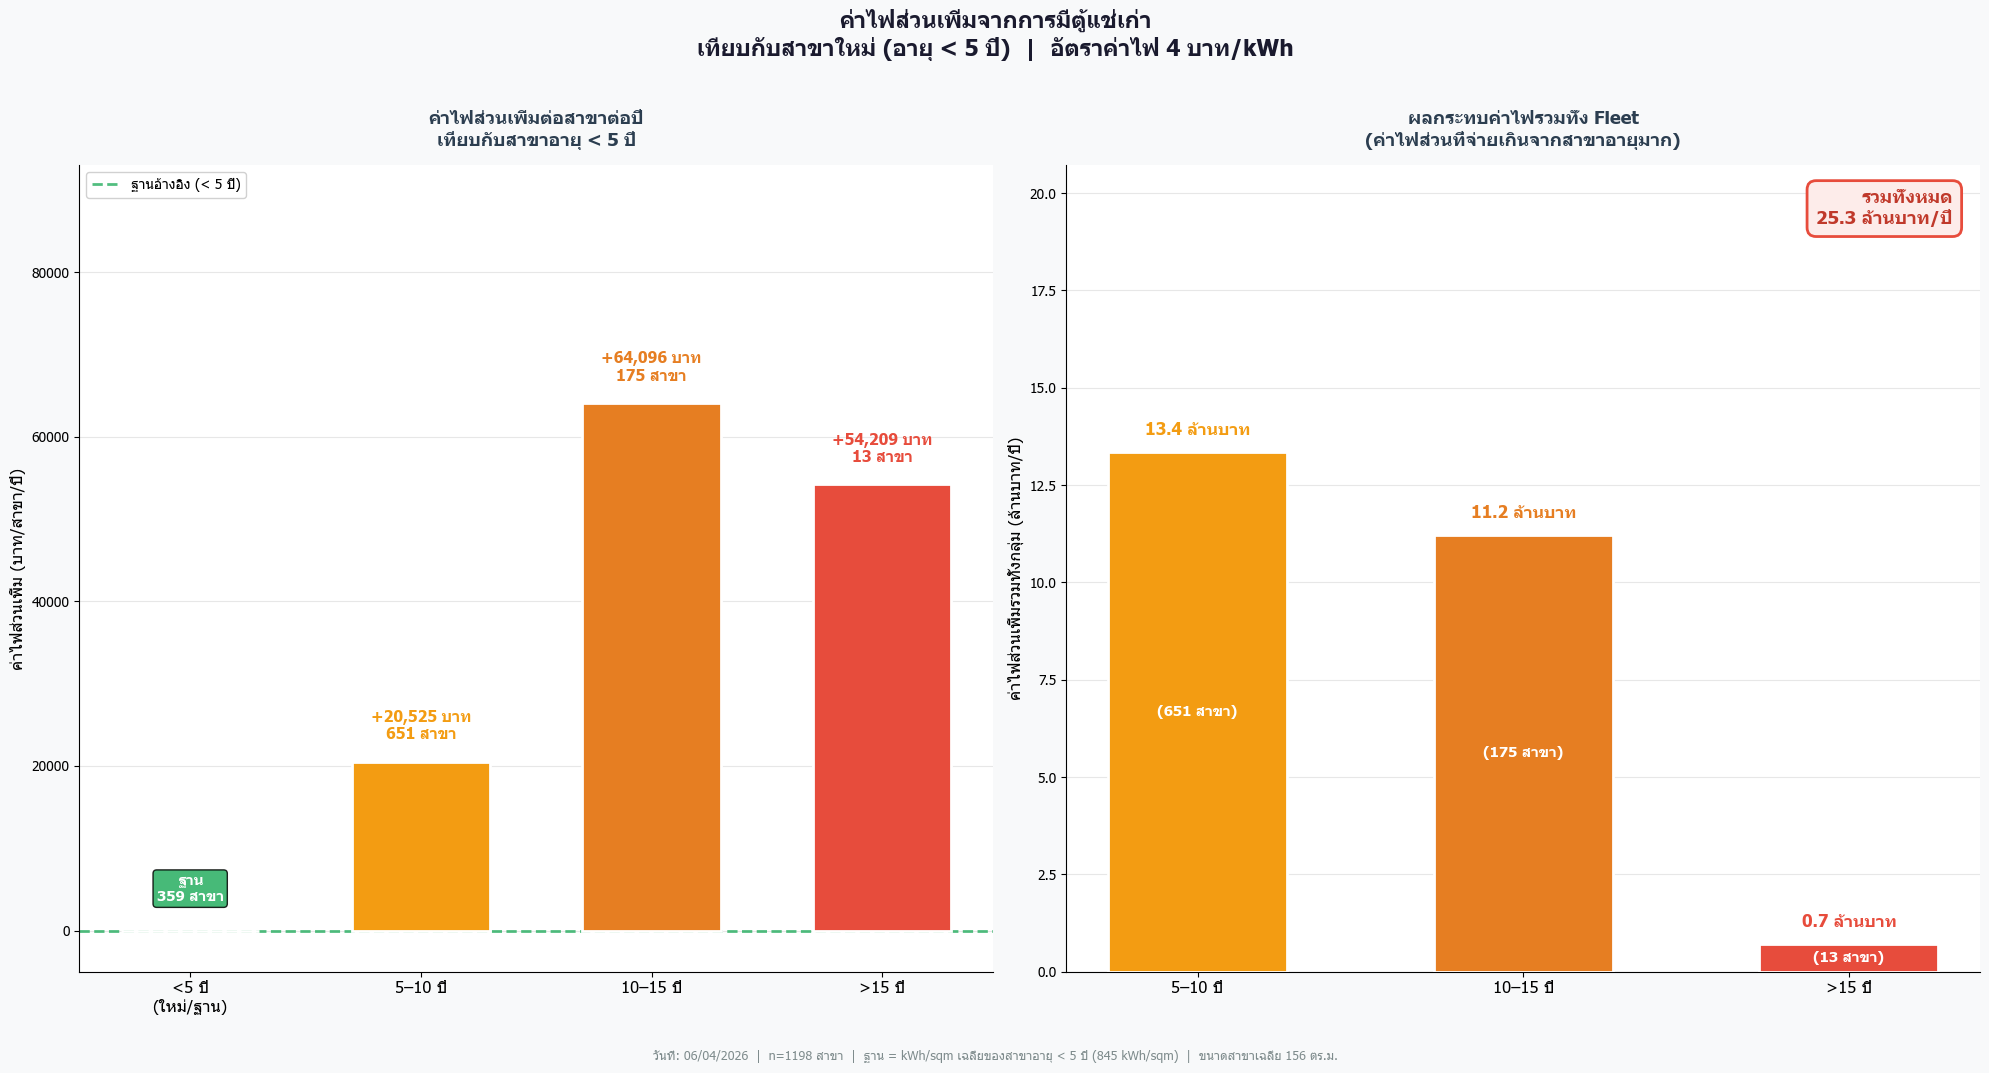


  ค่าไฟส่วนเพิ่มจากอายุตู้แช่  |  อัตรา 4 บาท/kWh
  กลุ่มอายุ          จำนวนสาขา   kWh/sqm เฉลี่ย      เพิ่มกว่าฐาน     บาท/สาขา/ปี   รวมทั้งกลุ่ม (บาท/ปี)
  ------------------------------------------------------------------------
  <5 ปี (ใหม่/ฐาน)         359          845.4          +0.0 kWh/sqm            +0 บาท                   0 บาท  ◀ ฐาน
  5–10 ปี                  651          880.6         +35.2 kWh/sqm       +20,525 บาท          13,361,450 บาท
  10–15 ปี                 175          942.4         +97.0 kWh/sqm       +64,096 บาท          11,216,842 บาท
  >15 ปี                    13          923.1         +77.7 kWh/sqm       +54,209 บาท             704,720 บาท

  รวมค่าไฟส่วนเกินทั้ง fleet: 25,283,013 บาท/ปี  (25.3 ล้านบาท/ปี)


In [40]:
# ═══════════════════════════════════════════════════════════════════
# 7.  ค่าไฟส่วนเพิ่มจากอายุตู้แช่  |  อัตรา 4 บาท / kWh
# ═══════════════════════════════════════════════════════════════════
KWH_RATE = 4.0   # บาท ต่อ 1 kWh

ev = energy_valid.dropna(subset=['Store Age (yrs)', 'kWh/sqm 2025', 'Net sqm']).copy()

age_cuts   = [0,  5,  10, 15, 99]
age_labels_clean = ['<5 ปี\n(ใหม่/ฐาน)', '5–10 ปี', '10–15 ปี', '>15 ปี']
ev['Age Group'] = pd.cut(ev['Store Age (yrs)'], bins=age_cuts,
                         labels=age_labels_clean, right=True)

grp = (ev.groupby('Age Group', observed=True)
         .agg(n        = ('kWh/sqm 2025', 'count'),
              kwh_mean = ('kWh/sqm 2025', 'mean'),
              kwh_std  = ('kWh/sqm 2025', 'std'),
              sqm_mean = ('Net sqm',      'mean'))
         .reset_index())

baseline_kwh = grp.loc[grp['Age Group'] == age_labels_clean[0], 'kwh_mean'].values[0]
baseline_sqm = grp.loc[grp['Age Group'] == age_labels_clean[0], 'sqm_mean'].values[0]

grp['extra_kwh_sqm']    = grp['kwh_mean'] - baseline_kwh
grp['extra_kwh_store']  = grp['extra_kwh_sqm'] * grp['sqm_mean']
grp['extra_baht_store'] = grp['extra_kwh_store'] * KWH_RATE
grp['total_baht_fleet'] = grp['extra_baht_store'] * grp['n']

pos_mask = grp['total_baht_fleet'] > 0
total_extra_M = grp.loc[pos_mask, 'total_baht_fleet'].sum() / 1e6

# ── Plot ───────────────────────────────────────────────────────────
fig2, axes = plt.subplots(1, 2, figsize=(20, 10), facecolor='#f8f9fa')
fig2.suptitle(
    f'ค่าไฟส่วนเพิ่มจากการมีตู้แช่เก่า\n'
    f'เทียบกับสาขาใหม่ (อายุ < 5 ปี)  |  อัตราค่าไฟ {KWH_RATE:.0f} บาท/kWh',
    fontsize=16, fontweight='bold', color='#1a1a2e', y=1.02)

bar_c = ['#27ae60', '#f39c12', '#e67e22', '#e74c3c']
DARK  = '#2c3e50'

# ── Left: ค่าไฟส่วนเพิ่ม (บาท/สาขา/ปี) ────────────────────────────
ax1 = axes[0]
extra_vals = grp['extra_baht_store'].values
bars1 = ax1.bar(range(4), extra_vals, color=bar_c,
                edgecolor='white', linewidth=2, zorder=3, width=0.6)

ax1.axhline(0, color='#27ae60', lw=2, ls='--', alpha=0.8, label='ฐานอ้างอิง (< 5 ปี)')

# explicit y-limit to prevent axis blow-up
y_top = max(extra_vals) * 1.45
ax1.set_ylim(-5000, y_top)

for i, (bar, row) in enumerate(zip(bars1, grp.itertuples())):
    extra_b = row.extra_baht_store
    n_s     = row.n
    bar_top = max(extra_b, 0)
    offset  = y_top * 0.025   # 2.5% of axis range as gap
    if i == 0:
        # ฐาน — label ใน bar
        ax1.text(bar.get_x()+bar.get_width()/2, y_top * 0.035,
                 f'ฐาน\n{n_s} สาขา',
                 ha='center', va='bottom', fontsize=10.5, fontweight='bold',
                 color='white',
                 bbox=dict(boxstyle='round,pad=0.25', facecolor='#27ae60', alpha=0.85))
    else:
        ax1.text(bar.get_x()+bar.get_width()/2, bar_top + offset,
                 f'+{extra_b:,.0f} บาท\n{n_s} สาขา',
                 ha='center', va='bottom', fontsize=11, fontweight='bold',
                 color=bar_c[i])

ax1.set_xticks(range(4))
ax1.set_xticklabels(age_labels_clean, fontsize=12)
ax1.set_ylabel('ค่าไฟส่วนเพิ่ม (บาท/สาขา/ปี)', fontsize=12)
ax1.set_title('ค่าไฟส่วนเพิ่มต่อสาขาต่อปี\nเทียบกับสาขาอายุ < 5 ปี',
              fontsize=13, fontweight='bold', color=DARK, pad=14)
ax1.legend(fontsize=10, framealpha=0.9, loc='upper left')
ax1.yaxis.grid(True, alpha=0.3); ax1.set_axisbelow(True)
ax1.spines[['top','right']].set_visible(False)

# ── Right: ผลกระทบรวมทั้งกลุ่ม (ล้านบาท/ปี) ──────────────────────
ax2 = axes[1]
bars2_x   = np.array([1, 2, 3])
bars2_y   = grp.loc[pos_mask, 'total_baht_fleet'].values / 1e6
bars2_n   = grp.loc[pos_mask, 'n'].values
bars2_c   = [bar_c[1], bar_c[2], bar_c[3]]
bars2_lbl = [age_labels_clean[1], age_labels_clean[2], age_labels_clean[3]]

b2_bars = ax2.bar(bars2_x, bars2_y, color=bars2_c,
                  edgecolor='white', linewidth=2, zorder=3, width=0.55)

# y-limit: leave 35% headroom for label + total box
ax2.set_ylim(0, bars2_y.max() * 1.55)

for bar, val, n_s in zip(b2_bars, bars2_y, bars2_n):
    # value above bar
    ax2.text(bar.get_x()+bar.get_width()/2, val + bars2_y.max()*0.025,
             f'{val:.1f} ล้านบาท',
             ha='center', va='bottom', fontsize=12, fontweight='bold',
             color=bar.get_facecolor())
    # n จำนวนสาขา inside bar
    ax2.text(bar.get_x()+bar.get_width()/2, val * 0.5,
             f'({n_s} สาขา)',
             ha='center', va='center', fontsize=10.5, fontweight='bold',
             color='white')

# "รวมทั้งหมด" box — placed at axes-relative coords, top-right, clear of title
ax2.text(0.97, 0.97,
         f'รวมทั้งหมด\n{total_extra_M:.1f} ล้านบาท/ปี',
         ha='right', va='top', fontsize=13, fontweight='bold', color='#c0392b',
         transform=ax2.transAxes, zorder=8,
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#fdecea',
                   edgecolor='#e74c3c', linewidth=2))

ax2.set_xticks(bars2_x)
ax2.set_xticklabels(bars2_lbl, fontsize=12)
ax2.set_ylabel('ค่าไฟส่วนเพิ่มรวมทั้งกลุ่ม (ล้านบาท/ปี)', fontsize=12)
ax2.set_title('ผลกระทบค่าไฟรวมทั้ง Fleet\n(ค่าไฟส่วนที่จ่ายเกินจากสาขาอายุมาก)',
              fontsize=13, fontweight='bold', color=DARK, pad=14)
ax2.yaxis.grid(True, alpha=0.3); ax2.set_axisbelow(True)
ax2.spines[['top','right']].set_visible(False)

fig2.text(0.5, -0.03,
    f'วันที่: {TODAY.strftime("%d/%m/%Y")}  |  n={len(ev)} สาขา  |  '
    f'ฐาน = kWh/sqm เฉลี่ยของสาขาอายุ < 5 ปี ({baseline_kwh:.0f} kWh/sqm)  |  '
    f'ขนาดสาขาเฉลี่ย {baseline_sqm:.0f} ตร.ม.',
    ha='center', fontsize=9, color='#7f8c8d', style='italic')

plt.tight_layout()
DASH4 = r'G:\My Drive\00. Web Projects\Air_Ref_Servey\Pyhon ANL\Age_Energy_CostImpact.png'
plt.savefig(DASH4, dpi=150, bbox_inches='tight', facecolor=fig2.get_facecolor())
plt.show()

# ── ตารางสรุปตัวเลข ──────────────────────────────────────────────
print(f"\n{'='*72}")
print(f"  ค่าไฟส่วนเพิ่มจากอายุตู้แช่  |  อัตรา {KWH_RATE:.0f} บาท/kWh")
print(f"{'='*72}")
print(f"  {'กลุ่มอายุ':<16}  {'จำนวนสาขา':>10}  {'kWh/sqm เฉลี่ย':>15}  "
      f"{'เพิ่มกว่าฐาน':>16}  {'บาท/สาขา/ปี':>14}  {'รวมทั้งกลุ่ม (บาท/ปี)':>22}")
print(f"  {'-'*72}")
for _, row in grp.iterrows():
    mark = '  ◀ ฐาน' if row['Age Group'] == age_labels_clean[0] else ''
    lbl  = str(row['Age Group']).replace('\n', ' ')
    print(f"  {lbl:<18}  {row['n']:>8,}  {row['kwh_mean']:>13.1f}  "
          f"  {row['extra_kwh_sqm']:>+10.1f} kWh/sqm"
          f"  {row['extra_baht_store']:>+12,.0f} บาท"
          f"  {row['total_baht_fleet']:>18,.0f} บาท{mark}")
print(f"\n  รวมค่าไฟส่วนเกินทั้ง fleet: {grp.loc[pos_mask,'total_baht_fleet'].sum():,.0f} บาท/ปี"
      f"  ({total_extra_M:.1f} ล้านบาท/ปี)")
print(f"{'='*72}")